In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

# To show max 10 columns. Too many will be truncated with ...
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10) # To avoid data overlapping due to larger number of columns
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'center')

# Display the first 10 records
print(df.head(10))
print(f"Number of rows: {len(df)}")


   Gender   Age  Height  Weight family_history_with_overweight  ... FAF   TUE     CALC            MTRANS              NObeyesdad     
0  Female  21.0   1.62    64.0                yes               ...  0.0  1.0          no  Public_Transportation        Normal_Weight
1  Female  21.0   1.52    56.0                yes               ...  3.0  0.0   Sometimes  Public_Transportation        Normal_Weight
2    Male  23.0   1.80    77.0                yes               ...  2.0  1.0  Frequently  Public_Transportation        Normal_Weight
3    Male  27.0   1.80    87.0                 no               ...  2.0  0.0  Frequently                Walking   Overweight_Level_I
4    Male  22.0   1.78    89.8                 no               ...  0.0  0.0   Sometimes  Public_Transportation  Overweight_Level_II
5    Male  29.0   1.62    53.0                 no               ...  0.0  0.0   Sometimes             Automobile        Normal_Weight
6  Female  23.0   1.50    55.0                yes             

In [2]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


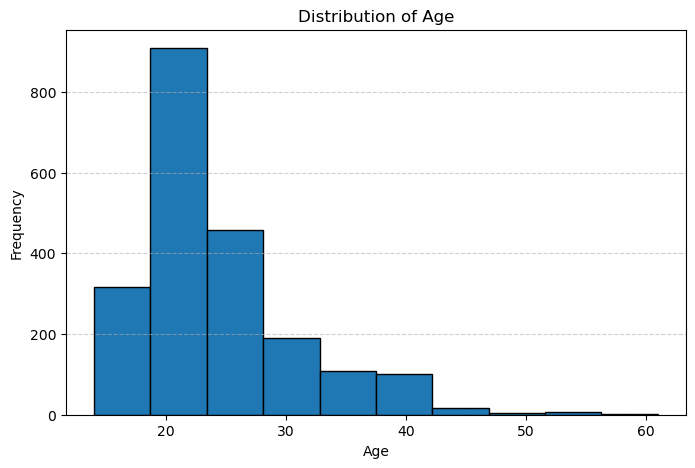

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10, edgecolor='black')  
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

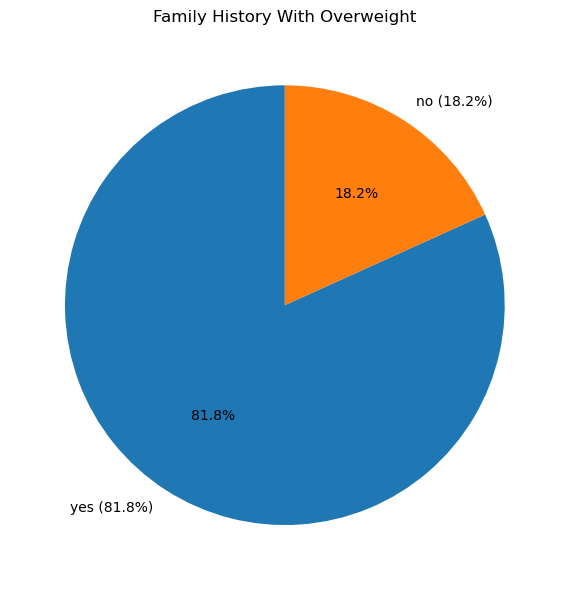

In [4]:
counts = df['family_history_with_overweight'].value_counts()
labels = [f"{idx} ({count/sum(counts)*100:.1f}%)" for idx, count in counts.items()]

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Family History With Overweight')
plt.tight_layout()
plt.show()


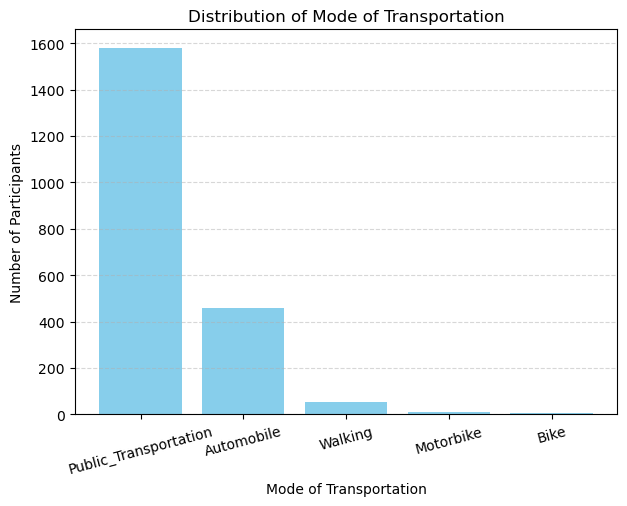

In [5]:
counts = df['MTRANS'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values, color='skyblue')
plt.xlabel('Mode of Transportation')
plt.ylabel('Number of Participants')
plt.title('Distribution of Mode of Transportation')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.show()

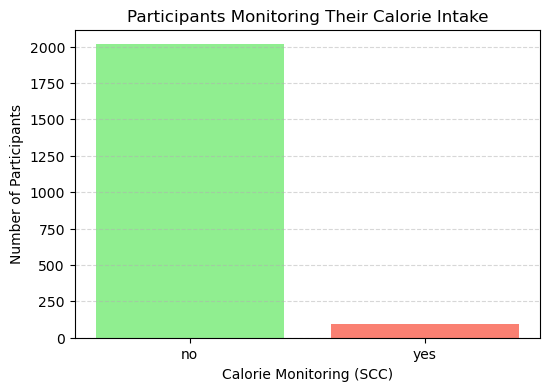

In [6]:
counts = df['SCC'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=['lightgreen', 'salmon'])
plt.xlabel('Calorie Monitoring (SCC)')
plt.ylabel('Number of Participants')
plt.title('Participants Monitoring Their Calorie Intake')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [7]:
mtrans_categories = df['MTRANS'].unique()

for mode in mtrans_categories:
    total = df[df['MTRANS'] == mode].shape[0]
    monitored = df[(df['MTRANS'] == mode) & (df['SCC'] == 'yes')].shape[0]
    percentage = (monitored / total) * 100 if total > 0 else 0
    print(f"{mode}: {monitored} out of {total} participants monitor calories ({percentage:.1f}%)")

Public_Transportation: 74 out of 1580 participants monitor calories (4.7%)
Walking: 6 out of 56 participants monitor calories (10.7%)
Automobile: 13 out of 457 participants monitor calories (2.8%)
Motorbike: 2 out of 11 participants monitor calories (18.2%)
Bike: 1 out of 7 participants monitor calories (14.3%)


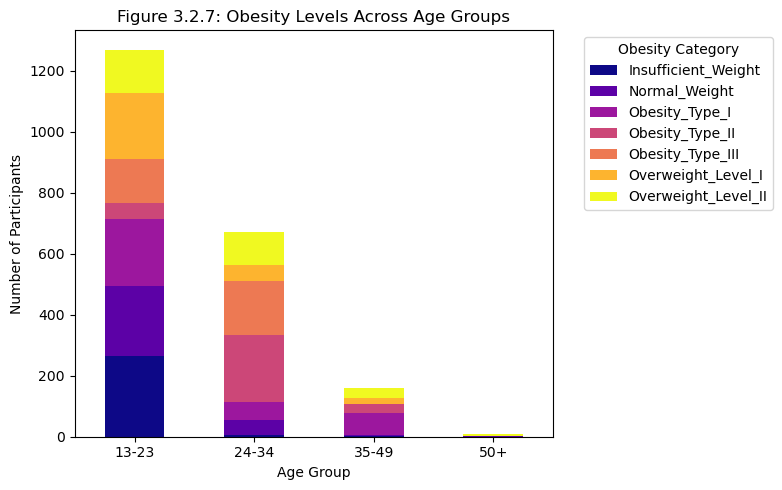

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

bins = [13, 24, 35, 50, 100]
labels = ['13-23','24-34','35-49', '50+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_obesity = df.groupby(['AgeGroup', 'NObeyesdad']).size().unstack(fill_value=0)

age_obesity.plot(kind='bar', stacked=True, figsize=(8,5), colormap='plasma')
plt.xlabel('Age Group')
plt.ylabel('Number of Participants')
plt.title('Figure 3.2.7: Obesity Levels Across Age Groups')
plt.legend(title='Obesity Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
for age_group in labels:
    age_df = df[df['AgeGroup'] == age_group]
    total = age_df.shape[0]
    if total == 0:
        continue
    print(f"Age Group {age_group} (Total: {total} participants)")
    for category, count in age_df['NObeyesdad'].value_counts().items():
        percent = (count / total) * 100
        print(f"  {category}: {count} ({percent:.1f}%)")
    print()

Age Group 13-23 (Total: 1269 participants)
  Insufficient_Weight: 264 (20.8%)
  Normal_Weight: 230 (18.1%)
  Obesity_Type_I: 221 (17.4%)
  Overweight_Level_I: 214 (16.9%)
  Obesity_Type_III: 146 (11.5%)
  Overweight_Level_II: 143 (11.3%)
  Obesity_Type_II: 51 (4.0%)

Age Group 24-34 (Total: 671 participants)
  Obesity_Type_II: 217 (32.3%)
  Obesity_Type_III: 178 (26.5%)
  Overweight_Level_II: 107 (15.9%)
  Obesity_Type_I: 59 (8.8%)
  Overweight_Level_I: 54 (8.0%)
  Normal_Weight: 49 (7.3%)
  Insufficient_Weight: 7 (1.0%)

Age Group 35-49 (Total: 161 participants)
  Obesity_Type_I: 70 (43.5%)
  Overweight_Level_II: 34 (21.1%)
  Obesity_Type_II: 29 (18.0%)
  Overweight_Level_I: 21 (13.0%)
  Normal_Weight: 6 (3.7%)
  Insufficient_Weight: 1 (0.6%)

Age Group 50+ (Total: 10 participants)
  Overweight_Level_II: 6 (60.0%)
  Normal_Weight: 2 (20.0%)
  Obesity_Type_I: 1 (10.0%)
  Overweight_Level_I: 1 (10.0%)



In [10]:
print(df['Age'].describe())

count    2111.000000
mean       24.312600
std         6.345968
min        14.000000
25%        19.947192
50%        22.777890
75%        26.000000
max        61.000000
Name: Age, dtype: float64


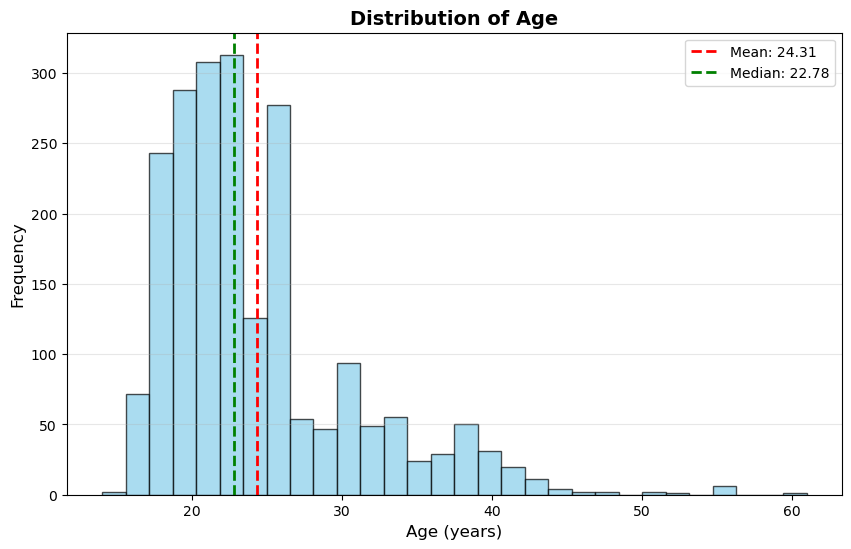

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.2f}')
plt.axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Age"].median():.2f}')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Age', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('age_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

Number of outliers: 168


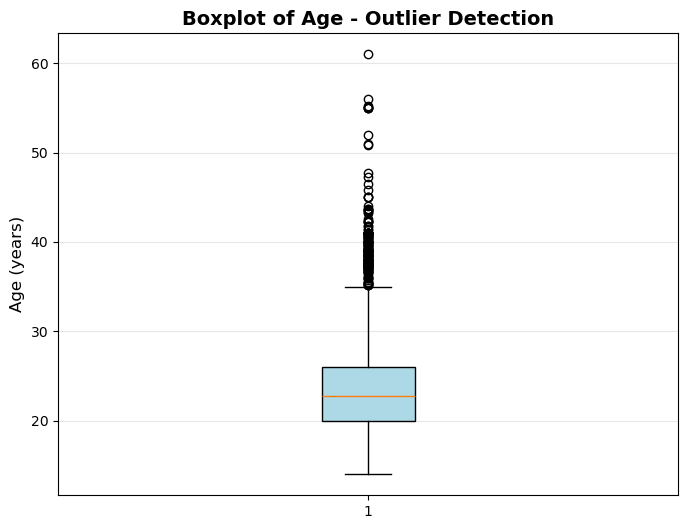

In [12]:
age_stats = df['Age'].describe().to_frame()

# Check for outliers
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Age'] < Q1 - 1.5*IQR) | (df['Age'] > Q3 + 1.5*IQR)]
print(f"Number of outliers: {len(outliers)}")

plt.figure(figsize=(8, 6))
box = plt.boxplot(df['Age'], vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
plt.ylabel('Age (years)', fontsize=12)
plt.title('Boxplot of Age - Outlier Detection', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.savefig('age_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1400x600 with 0 Axes>

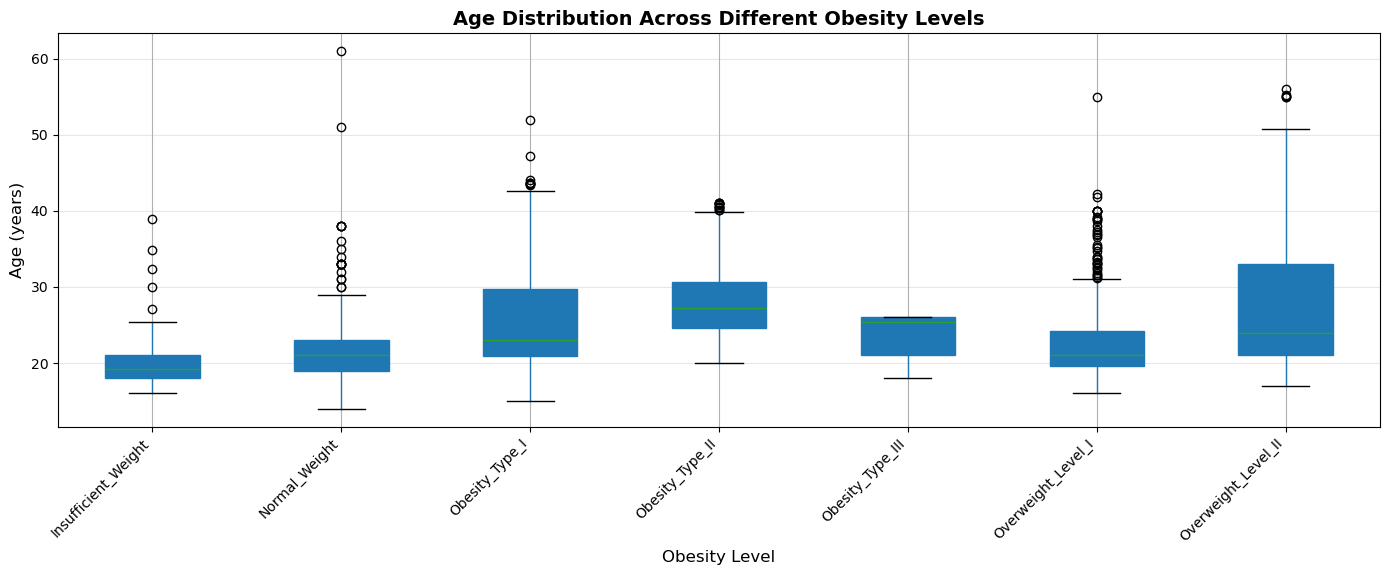

In [13]:
plt.figure(figsize=(14, 6))
df.boxplot(column='Age', by='NObeyesdad', figsize=(14, 6), patch_artist=True)
plt.suptitle('')
plt.xlabel('Obesity Level', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.title('Age Distribution Across Different Obesity Levels', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('age_by_obesity.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
ages = df['Age']

# ---- BASIC STATS ----
age_min = ages.min()
age_max = ages.max()
age_range = age_max - age_min

mean_age = ages.mean()
median_age = ages.median()
std_age = ages.std()

# ---- OUTLIERS USING IQR ----
Q1 = ages.quantile(0.25)
Q3 = ages.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = ages[ages > upper_bound]
num_outliers = len(outliers)

# ---- Example Obesity Relationship (customize depending on data) ----
# Here we check if obesity level tends to increase with age by comparing means
if 'Obesity' in df.columns:
    obesity_trend = df.groupby('Obesity')['Age'].mean().sort_values()
else:
    obesity_trend = None

# ---- PRINT FINDINGS ----
print("**Key Findings:**")
print(f"- **Range:** {age_min} to {age_max} years ({age_range}-year span)")
print(f"- **Central Tendency:** Mean ({mean_age:.2f}) is {'higher' if mean_age > median_age else 'lower'} than median ({median_age:.2f}), suggesting {'right' if mean_age > median_age else 'left'} skew")
print(f"- **Variability:** Standard deviation of {std_age:.2f} years indicates moderate spread")
print(f"- **Outliers:** {num_outliers} outliers detected above age {upper_bound:.2f}")

if obesity_trend is not None:
    print("- **Obesity Relationship:**")
    print("  Average ages by obesity category:")
    for level, avg_age in obesity_trend.items():
        print(f"  - {level}: {avg_age:.2f} years")
else:
    print("- **Obesity Relationship:** Add an 'Obesity' column to analyze patterns.")

**Key Findings:**
- **Range:** 14.0 to 61.0 years (47.0-year span)
- **Central Tendency:** Mean (24.31) is higher than median (22.78), suggesting right skew
- **Variability:** Standard deviation of 6.35 years indicates moderate spread
- **Outliers:** 168 outliers detected above age 35.08
- **Obesity Relationship:** Add an 'Obesity' column to analyze patterns.


In [15]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad', 'AgeGroup'], dtype='object')

In [16]:
ages = df['Age']
age_min = ages.min()
age_max = ages.max()
age_range = age_max - age_min

mean_age = ages.mean()
median_age = ages.median()
std_age = ages.std()

Q1 = ages.quantile(0.25)
Q3 = ages.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = ages[ages > upper_bound]
num_outliers = len(outliers)

obesity_trend = df.groupby('NObeyesdad')['Age'].mean().sort_values()

print("**Key Findings:**")
print(f"- **Range:** {age_min} to {age_max} years ({age_range}-year span)")
print(f"- **Central Tendency:** Mean ({mean_age:.2f}) is {'higher' if mean_age > median_age else 'lower'} than median ({median_age:.2f}), suggesting {'right' if mean_age > median_age else 'left'} skew")
print(f"- **Variability:** Standard deviation of {std_age:.2f} years indicates moderate spread")
print(f"- **Outliers:** {num_outliers} outliers detected above age {upper_bound:.2f}")

print("- **Obesity Relationship:**")
print("  Average age per obesity category:")
for level, avg_age in obesity_trend.items():
    print(f"  - {level}: {avg_age:.2f} years")

**Key Findings:**
- **Range:** 14.0 to 61.0 years (47.0-year span)
- **Central Tendency:** Mean (24.31) is higher than median (22.78), suggesting right skew
- **Variability:** Standard deviation of 6.35 years indicates moderate spread
- **Outliers:** 168 outliers detected above age 35.08
- **Obesity Relationship:**
  Average age per obesity category:
  - Insufficient_Weight: 19.78 years
  - Normal_Weight: 21.74 years
  - Overweight_Level_I: 23.42 years
  - Obesity_Type_III: 23.50 years
  - Obesity_Type_I: 25.88 years
  - Overweight_Level_II: 27.00 years
  - Obesity_Type_II: 28.23 years


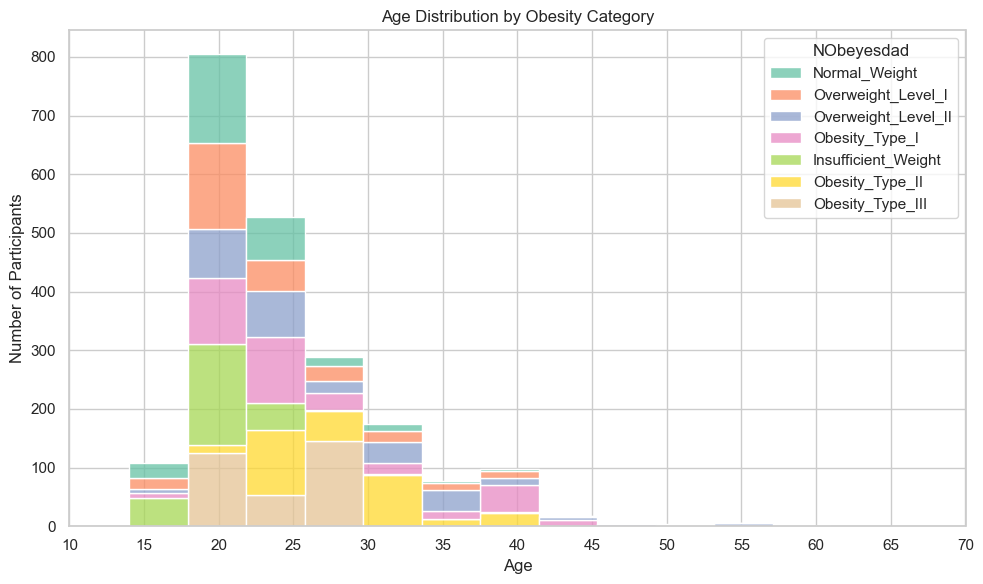

In [17]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='Age',
    hue='NObeyesdad',
    multiple='stack',   # stack bars
    bins=12,
    palette='Set2',
)

plt.title("Age Distribution by Obesity Category")
plt.xlabel("Age")
plt.ylabel("Number of Participants")
plt.xticks(range(10, 71, 5))
plt.tight_layout()
plt.show()

In [18]:
import scipy.stats as stats

groups = [df[df['NObeyesdad'] == category]['Age'] for category in df['NObeyesdad'].unique()]
F_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA test: F = {F_stat:.2f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("This indicates significant age differences across obesity levels.")
else:
    print("No significant age differences across obesity levels were found.")

ANOVA test: F = 77.95, p = 0.0000
This indicates significant age differences across obesity levels.


In [19]:
height_stats = df['Height'].describe()
display(height_stats)

count    2111.000000
mean        1.701677
std         0.093305
min         1.450000
25%         1.630000
50%         1.700499
75%         1.768464
max         1.980000
Name: Height, dtype: float64

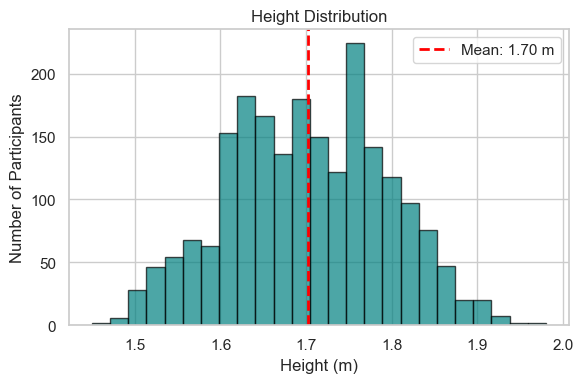

In [20]:
plt.figure(figsize=(6,4)) 
plt.hist(df['Height'], bins=25, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(df['Height'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {df['Height'].mean():.2f} m")
plt.title("Height Distribution")
plt.xlabel("Height (m)")
plt.ylabel("Number of Participants")
plt.legend()
plt.tight_layout()
plt.show()

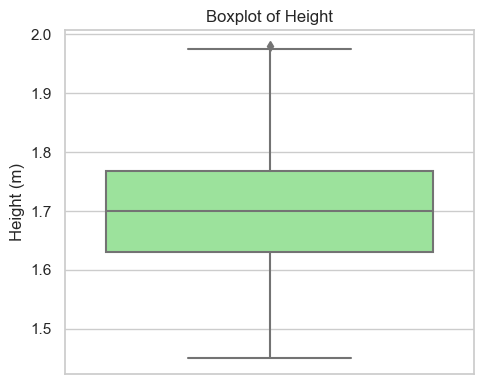

Number of outliers: 11


,Gender,Age,Height,Weight,family_history_with_overweight,...,TUE,CALC,MTRANS,NObeyesdad,AgeGroup
183,Female,23.000000,1.480000,60.000000,yes,...,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,13-23
334,Female,18.000000,1.450000,53.000000,no,...,2.000000,Frequently,Public_Transportation,Overweight_Level_I,13-23
349,Male,20.000000,1.980000,125.000000,yes,...,1.000000,Sometimes,Public_Transportation,Obesity_Type_I,13-23
865,Female,18.000000,1.456346,55.523481,no,...,1.783319,Sometimes,Public_Transportation,Overweight_Level_I,13-23
866,Female,18.000000,1.498561,55.376512,no,...,0.978574,Sometimes,Public_Transportation,Overweight_Level_I,13-23
...,...,...,...,...,...,...,...,...,...,...,...
990,Female,22.154854,1.481682,61.373868,yes,...,0.509396,no,Public_Transportation,Overweight_Level_II,13-23
1093,Female,21.082384,1.486484,60.117993,yes,...,0.969097,no,Public_Transportation,Overweight_Level_II,13-23
1135,Female,21.959940,1.483284,62.894283,yes,...,0.575848,no,Public_Transportation,Overweight_Level_II,13-23
1166,Female,21.821650,1.491441,62.269912,yes,...,0.517430,no,Public_Transportation,Overweight_Level_II,13-23


In [21]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Height'], color='lightgreen')
plt.title("Boxplot of Height")
plt.ylabel("Height (m)")
plt.tight_layout()
plt.show()

outliers = df[(df['Height'] < 1.50) | (df['Height'] > 1.95)]
print(f"Number of outliers: {len(outliers)}")
display(outliers)


In [22]:
weight_stats = df['Weight'].describe()
display(weight_stats)

count    2111.000000
mean       86.586058
std        26.191172
min        39.000000
25%        65.473343
50%        83.000000
75%       107.430682
max       173.000000
Name: Weight, dtype: float64

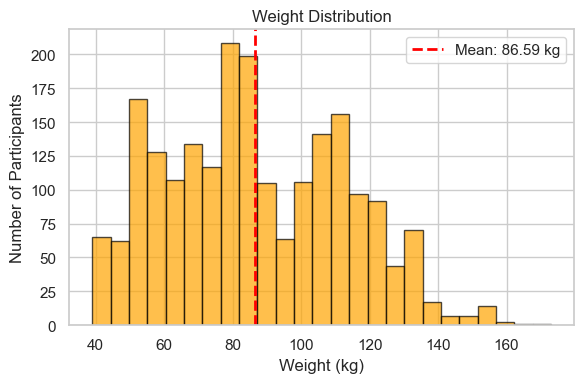

In [23]:
plt.figure(figsize=(6,4))
plt.hist(df['Weight'], bins=25, color='orange', edgecolor='black', alpha=0.7)

plt.axvline(df['Weight'].mean(), color='red', linestyle='dashed', linewidth=2, 
            label=f"Mean: {df['Weight'].mean():.2f} kg")

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Participants")
plt.legend()
plt.tight_layout()
plt.show()

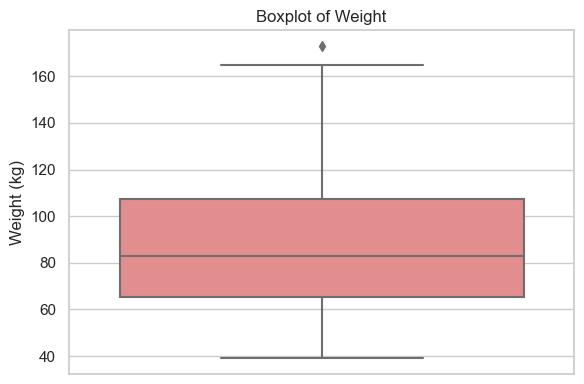

Number of outliers: 6


,Gender,Age,Height,Weight,family_history_with_overweight,...,TUE,CALC,MTRANS,NObeyesdad,AgeGroup
344,Male,18.000000,1.870000,173.000000,yes,...,1.000000,Sometimes,Public_Transportation,Obesity_Type_III,13-23
395,Female,20.000000,1.540000,39.000000,yes,...,2.000000,Sometimes,Public_Transportation,Insufficient_Weight,13-23
588,Female,18.530840,1.573816,39.850137,no,...,2.000000,Sometimes,Public_Transportation,Insufficient_Weight,13-23
589,Female,19.948140,1.530884,39.371523,no,...,0.720454,Sometimes,Public_Transportation,Insufficient_Weight,13-23
636,Female,19.054008,1.556611,39.695295,no,...,1.683261,Sometimes,Public_Transportation,Insufficient_Weight,13-23
725,Female,19.994543,1.537739,39.101805,no,...,1.626194,Sometimes,Public_Transportation,Insufficient_Weight,13-23


In [24]:
plt.figure(figsize=(6,4)) 
sns.boxplot(y=df['Weight'], color='lightcoral')
plt.title("Boxplot of Weight")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.show()

outliers_weight = df[(df['Weight'] < 40) | (df['Weight'] > 170)]
print(f"Number of outliers: {len(outliers_weight)}")
display(outliers_weight)

In [25]:
freq_table = df['family_history_with_overweight'].value_counts()
percent_table = df['family_history_with_overweight'].value_counts(normalize=True) * 100

freq_df = pd.DataFrame({
    'Count': freq_table,
    'Percentage (%)': percent_table.round(1)
})
display(freq_df)

,Count,Percentage (%)
yes,1726,81.8
no,385,18.2


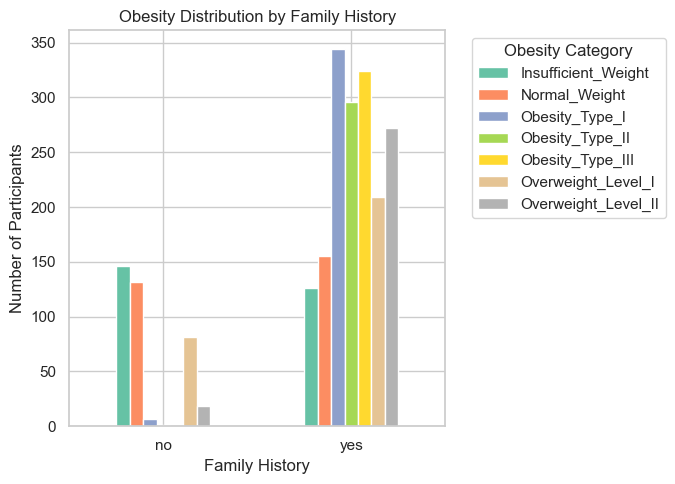

In [26]:
obesity_by_family = df.groupby(['family_history_with_overweight', 'NObeyesdad']).size().unstack(fill_value=0)

obesity_by_family.plot(kind='bar', figsize=(7,5), colormap='Set2')
plt.title("Obesity Distribution by Family History")
plt.ylabel("Number of Participants")
plt.xlabel("Family History")
plt.xticks(rotation=0)
plt.legend(title="Obesity Category", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

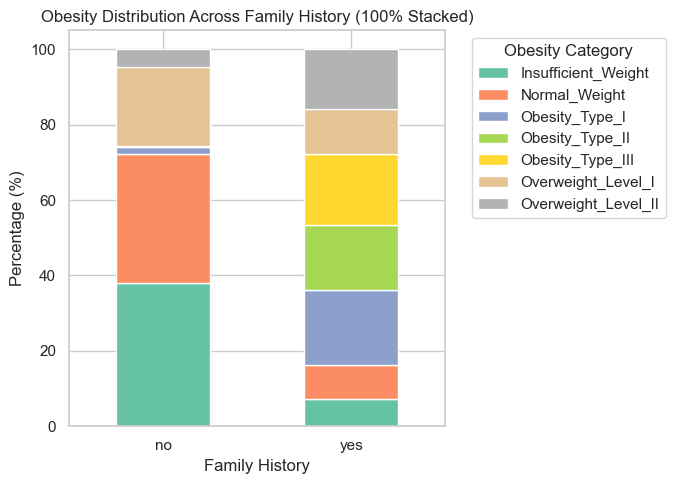

In [27]:
obesity_percent = obesity_by_family.div(obesity_by_family.sum(axis=1), axis=0) * 100

obesity_percent.plot(kind='bar', stacked=True, figsize=(7,5), colormap='Set2')
plt.title("Obesity Distribution Across Family History (100% Stacked)")
plt.ylabel("Percentage (%)")
plt.xlabel("Family History")
plt.xticks(rotation=0)
plt.legend(title="Obesity Category", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [28]:
from scipy.stats import chi2_contingency

# Contingency table
contingency = pd.crosstab(df['family_history_with_overweight'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Highly significant association between family history and obesity levels.")
else:
    print("No significant association found.")

Chi-square test: χ² = 621.98, p = 0.0000
Highly significant association between family history and obesity levels.


In [29]:
# Obesity categories
obesity_categories = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']  # replace with your actual labels

# WITH family history
yes_total = 1726
yes_obese_count = df[(df['family_history_with_overweight'] == 'yes') & (df['NObeyesdad'].isin(obesity_categories))].shape[0]
yes_obese_pct = yes_obese_count / yes_total * 100

# WITHOUT family history
no_total = 385
no_obese_count = df[(df['family_history_with_overweight'] == 'no') & (df['NObeyesdad'].isin(obesity_categories))].shape[0]
no_obese_pct = no_obese_count / no_total * 100

# Risk amplification
risk_amp = yes_obese_pct / no_obese_pct if no_obese_pct != 0 else float('inf')

print(f"Obesity among WITH family history: {yes_obese_pct:.1f}%")
print(f"Obesity among WITHOUT family history: {no_obese_pct:.1f}%")
print(f"Risk amplification: {risk_amp:.1f}x")

Obesity among WITH family history: 55.9%
Obesity among WITHOUT family history: 2.1%
Risk amplification: 26.9x


In [30]:
scc_counts = df['SCC'].value_counts()
scc_percent = df['SCC'].value_counts(normalize=True) * 100

scc_df = pd.DataFrame({
    'Count': scc_counts,
    'Percentage (%)': scc_percent.round(1)
})

display(scc_df)

,Count,Percentage (%)
no,2015,95.5
yes,96,4.5


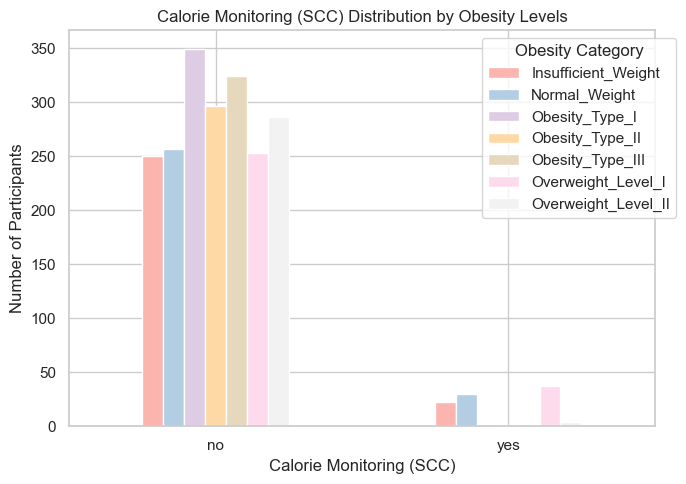

In [31]:
scc_by_obesity = df.groupby(['SCC', 'NObeyesdad']).size().unstack(fill_value=0)

scc_by_obesity.plot(kind='bar', figsize=(7,5), colormap='Pastel1')
plt.title("Calorie Monitoring (SCC) Distribution by Obesity Levels")
plt.ylabel("Number of Participants")
plt.xlabel("Calorie Monitoring (SCC)")
plt.xticks(rotation=0)
plt.legend(title="Obesity Category", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [32]:
from scipy.stats import chi2_contingency

# Contingency table
contingency_scc = pd.crosstab(df['SCC'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_scc)

print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("Interpretation: SCC is significantly related to obesity levels.")
else:
    print("Interpretation: SCC is not significantly related to obesity levels.")

Chi-square test: χ² = 123.02, p = 0.0000
Interpretation: SCC is significantly related to obesity levels.


In [33]:
mtrans_counts = df['MTRANS'].value_counts()
mtrans_percent = df['MTRANS'].value_counts(normalize=True) * 100

mtrans_df = pd.DataFrame({
    'Count': mtrans_counts,
    'Percentage (%)': mtrans_percent.round(1)
})

display(mtrans_df)

,Count,Percentage (%)
Public_Transportation,1580,74.8
Automobile,457,21.6
Walking,56,2.7
Motorbike,11,0.5
Bike,7,0.3


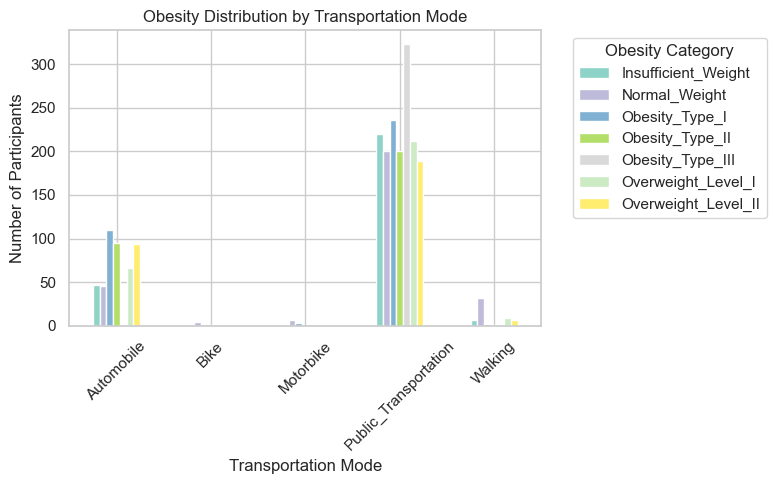

In [34]:
mtrans_by_obesity = df.groupby(['MTRANS', 'NObeyesdad']).size().unstack(fill_value=0)

mtrans_by_obesity.plot(kind='bar', figsize=(8,5), colormap='Set3')
plt.title("Obesity Distribution by Transportation Mode")
plt.ylabel("Number of Participants")
plt.xlabel("Transportation Mode")
plt.xticks(rotation=45)
plt.legend(title="Obesity Category", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

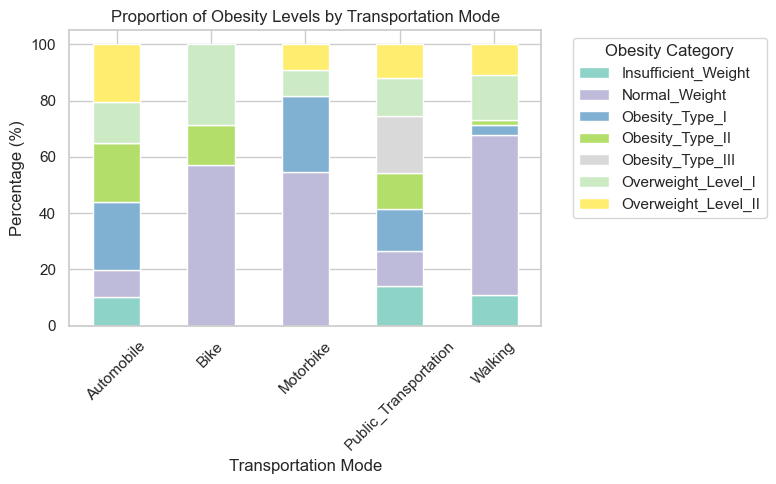

In [35]:
mtrans_percent_obesity = mtrans_by_obesity.div(mtrans_by_obesity.sum(axis=1), axis=0) * 100

mtrans_percent_obesity.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set3')
plt.title("Proportion of Obesity Levels by Transportation Mode")
plt.ylabel("Percentage (%)")
plt.xlabel("Transportation Mode")
plt.xticks(rotation=45)
plt.legend(title="Obesity Category", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()


In [36]:
contingency_mtrans = pd.crosstab(df['MTRANS'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_mtrans)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: MTRANS is significantly related to obesity levels.")
else:
    print("Interpretation: MTRANS is not significantly related to obesity levels.")

Chi-square test: χ² = 292.59, p = 0.0000
Interpretation: MTRANS is significantly related to obesity levels.


In [37]:
fcvc_desc = df['FCVC'].describe()
fcvc_mode = df['FCVC'].mode()[0]
print("Descriptive statistics for FCVC:")
print(fcvc_desc)
print(f"Most common value (mode): {fcvc_mode}")

Descriptive statistics for FCVC:
count    2111.000000
mean        2.419043
std         0.533927
min         1.000000
25%         2.000000
50%         2.385502
75%         3.000000
max         3.000000
Name: FCVC, dtype: float64
Most common value (mode): 3.0


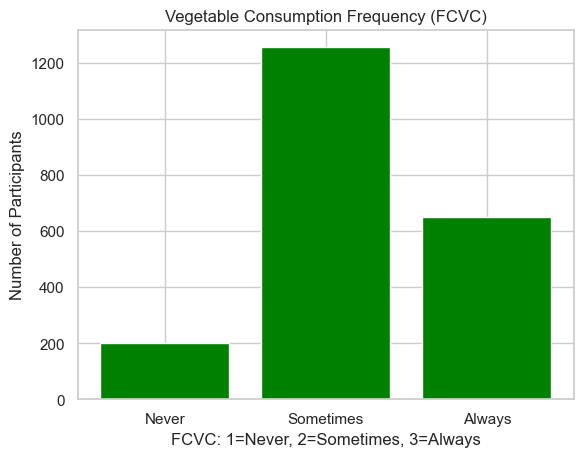

In [38]:
import matplotlib.pyplot as plt

df['FCVC'] = df['FCVC'].astype(int)
# Counts for FCVC
fcvc_counts = df['FCVC'].value_counts().sort_index()
# Basic bar chart
plt.bar(fcvc_counts.index, fcvc_counts.values, color='green')
plt.title("Vegetable Consumption Frequency (FCVC)")
plt.xlabel("FCVC: 1=Never, 2=Sometimes, 3=Always")
plt.ylabel("Number of Participants")
plt.xticks(fcvc_counts.index, ['Never', 'Sometimes', 'Always'])
plt.show()

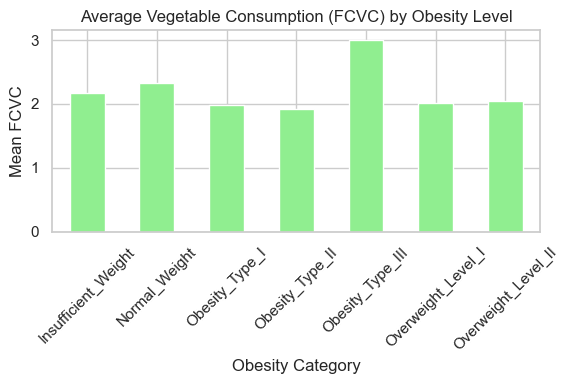

In [39]:
fcvc_by_obesity = df.groupby('NObeyesdad')['FCVC'].mean()

fcvc_by_obesity.plot(kind='bar', color='lightgreen', figsize=(6,4))
plt.title("Average Vegetable Consumption (FCVC) by Obesity Level")
plt.ylabel("Mean FCVC")
plt.xlabel("Obesity Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
print("Mean FCVC by obesity category:")
display(fcvc_by_obesity.round(2))

Mean FCVC by obesity category:


NObeyesdad
Insufficient_Weight    2.17
Normal_Weight          2.33
Obesity_Type_I         1.98
Obesity_Type_II        1.92
Obesity_Type_III       3.00
Overweight_Level_I     2.01
Overweight_Level_II    2.04
Name: FCVC, dtype: float64

In [41]:
fcvc_percent = df['FCVC'].value_counts(normalize=True) * 100
fcvc_table = pd.DataFrame({
    'Count': df['FCVC'].value_counts().sort_index(),
    'Percentage (%)': fcvc_percent.sort_index().round(1)
})
display(fcvc_table)

,Count,Percentage (%)
1,202,9.6
2,1257,59.5
3,652,30.9


In [42]:
fcvc_obesity_table = pd.crosstab(df['FCVC'], df['NObeyesdad'])
display(fcvc_obesity_table)

chi2, p, dof, expected = stats.chi2_contingency(fcvc_obesity_table)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: FCVC is significantly related to obesity levels.")
else:
    print("Interpretation: No significant relationship between FCVC and obesity levels.")

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FCVC,,,,,,,
1,37,18,33,50,0,37,27
2,152,155,291,222,0,213,224
3,83,114,27,25,324,40,39


Chi-square test: χ² = 995.79, p = 0.0000
Interpretation: FCVC is significantly related to obesity levels.


In [43]:
ncp_desc = df['NCP'].describe()
ncp_mode = df['NCP'].mode()[0]

print("Descriptive statistics for NCP:")
print(ncp_desc)

Descriptive statistics for NCP:
count    2111.000000
mean        2.685628
std         0.778039
min         1.000000
25%         2.658738
50%         3.000000
75%         3.000000
max         4.000000
Name: NCP, dtype: float64


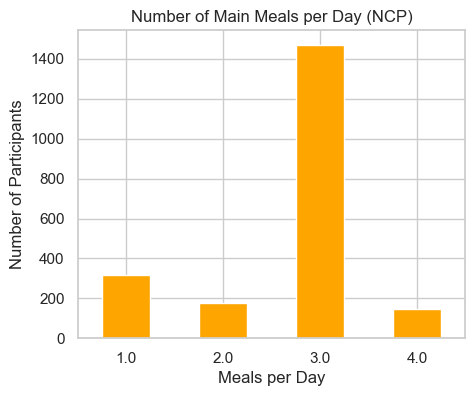

In [44]:
# Round the values in the NCP column to the nearest integer
df['NCP'] = df['NCP'].round()
ncp_counts = df['NCP'].value_counts().sort_index()

# Plot the bar chart
ncp_counts.plot(kind='bar', color='orange', figsize=(5,4))
plt.title("Number of Main Meals per Day (NCP)")
plt.xlabel("Meals per Day")
plt.ylabel("Number of Participants")
plt.xticks(rotation=0)
plt.show()


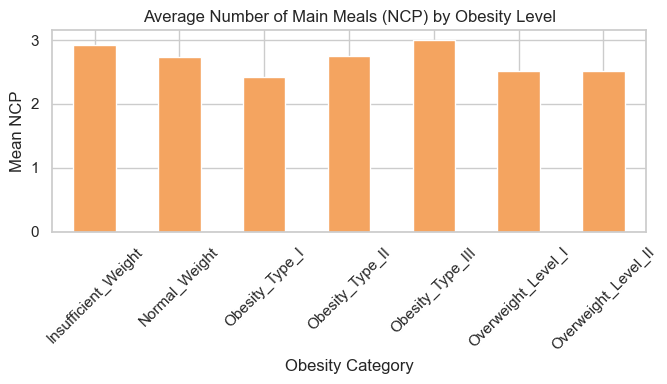

In [45]:
ncp_by_obesity = df.groupby('NObeyesdad')['NCP'].mean()

ncp_by_obesity.plot(kind='bar', color='sandybrown', figsize=(7,4))
plt.title("Average Number of Main Meals (NCP) by Obesity Level")
plt.ylabel("Mean NCP")
plt.xlabel("Obesity Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
print("Mean NCP by obesity category:")
display(ncp_by_obesity.round(2))

Mean NCP by obesity category:


NObeyesdad
Insufficient_Weight    2.93
Normal_Weight          2.74
Obesity_Type_I         2.42
Obesity_Type_II        2.75
Obesity_Type_III       3.00
Overweight_Level_I     2.51
Overweight_Level_II    2.51
Name: NCP, dtype: float64

In [47]:
ct_ncp = pd.crosstab(df['NCP'], df['NObeyesdad'])
print("Contingency Table:")
display(ct_ncp)

chi2, p, dof, expected = chi2_contingency(ct_ncp)
print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: NCP is significantly related to obesity levels.")
else:
    print("Interpretation: NCP is NOT significantly related to obesity levels.")


Contingency Table:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
NCP,,,,,,,
1.0,37,52,79,24,0,76,48
2.0,18,0,47,36,0,23,52
3.0,145,206,225,228,324,158,184
4.0,72,29,0,9,0,33,6



Chi-square test: χ² = 487.99, p = 0.0000
Interpretation: NCP is significantly related to obesity levels.


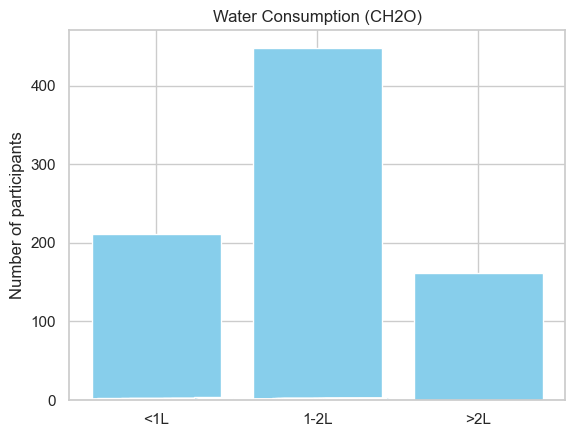

In [48]:
counts = df['CH2O'].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.bar(counts.index, counts, color='skyblue')
plt.xticks([1,2,3], ['<1L','1-2L','>2L'])
plt.ylabel('Number of participants')
plt.title('Water Consumption (CH2O)')
plt.show()

In [49]:
CH2O_desc = df['CH2O'].describe()
CH2O_mode = df['CH2O'].mode()[0]

print("Descriptive statistics for CH2O:")
print(CH2O_desc)

Descriptive statistics for CH2O:
count    2111.000000
mean        2.008011
std         0.612953
min         1.000000
25%         1.584812
50%         2.000000
75%         2.477420
max         3.000000
Name: CH2O, dtype: float64


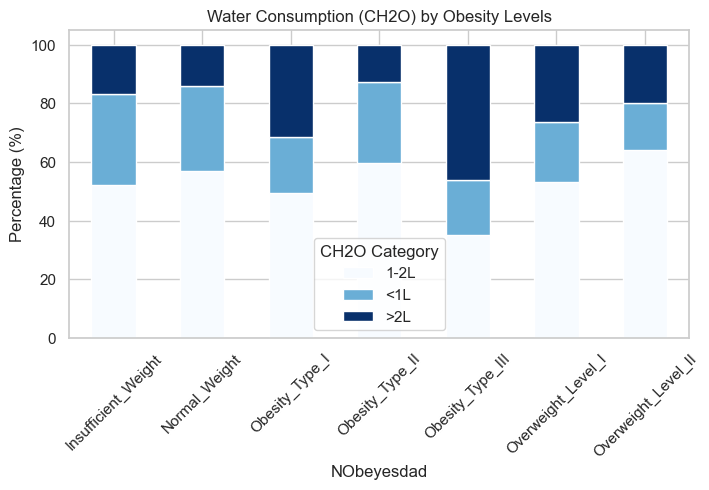

In [50]:
df['CH2O'] = df['CH2O'].round()
df['CH2O_cat'] = df['CH2O'].map({
    1: '<1L',
    2: '1-2L',
    3: '>2L'
})
df['CH2O_cat'] = df['CH2O_cat'].fillna('Other')
ct = pd.crosstab(df['CH2O_cat'], df['NObeyesdad'])
ct_percent = ct.div(ct.sum(axis=0), axis=1) * 100
ct_percent = ct_percent.round(1)
ct_percent.T.plot(kind='bar', stacked=True, colormap='Blues', figsize=(8,4))
plt.ylabel('Percentage (%)')
plt.title('Water Consumption (CH2O) by Obesity Levels')
plt.legend(title='CH2O Category')
plt.xticks(rotation=45)
plt.show()

In [51]:
ct = pd.crosstab(df['CH2O'], df['NObeyesdad'])
print("Contingency Table:")
print(ct)

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(ct)
print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: CH2O is significantly related to obesity levels.")
else:
    print("Interpretation: CH2O is NOT significantly related to obesity levels.")

Contingency Table:
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
CH2O                                                                                                                                      
1.0                  84                83              68              82                61                 60                  47        
2.0                 142               164             173             177               114                154                 186        
3.0                  46                40             110              38               149                 76                  57        

Chi-square test: χ² = 163.32, p = 0.0000
Interpretation: CH2O is significantly related to obesity levels.


In [52]:
ct_percent = ct.div(ct.sum(axis=0), axis=1) * 100
ct_percent = ct_percent.round(1)
ct_percent

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CH2O,,,,,,,
1.0,30.9,28.9,19.4,27.6,18.8,20.7,16.2
2.0,52.2,57.1,49.3,59.6,35.2,53.1,64.1
3.0,16.9,13.9,31.3,12.8,46.0,26.2,19.7


In [53]:
faf_desc = df['FAF'].describe()
faf_mode = df['FAF'].mode()[0]

print("Descriptive statistics for FAF:")
print(faf_desc)

Descriptive statistics for FAF:
count    2111.000000
mean        1.010298
std         0.850592
min         0.000000
25%         0.124505
50%         1.000000
75%         1.666678
max         3.000000
Name: FAF, dtype: float64


In [54]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad', 'AgeGroup', 'CH2O_cat'], dtype='object')

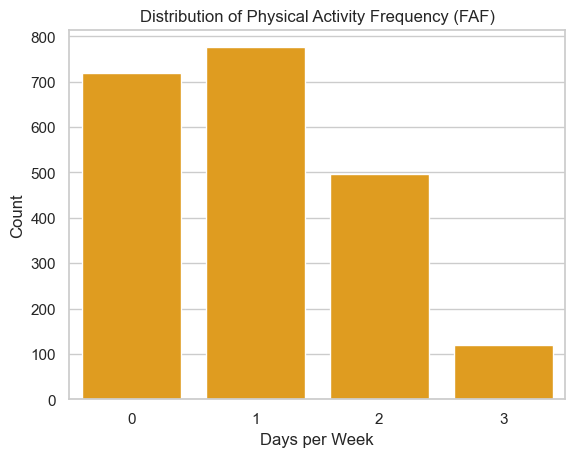

In [55]:
df['FAF'] = df['FAF'].round().astype('Int64')  # round to nearest whole number
df['FAF'] = df['FAF'].clip(0, 3)               # ensure valid range 0–3

sns.countplot(x='FAF', data=df, color='orange')
plt.title('Distribution of Physical Activity Frequency (FAF)')
plt.xlabel('Days per Week')
plt.ylabel('Count')
plt.show()

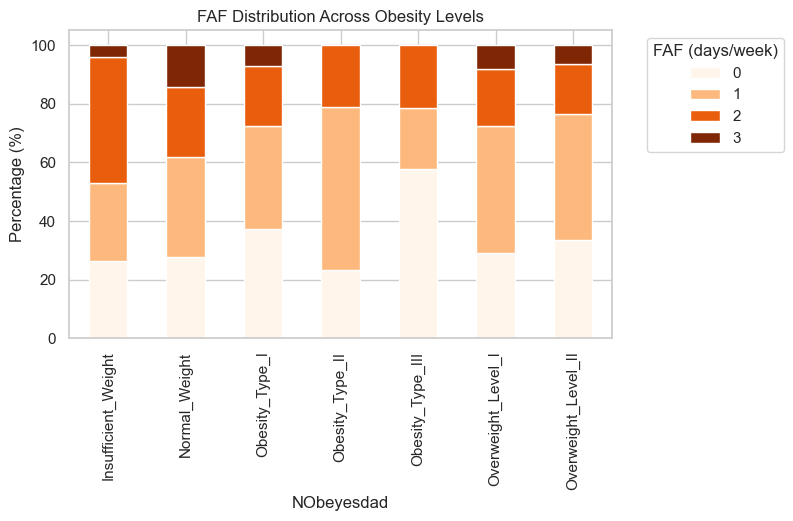

In [56]:
faf_obesity = df.groupby(['NObeyesdad','FAF']).size().unstack(fill_value=0)
faf_obesity_pct = faf_obesity.div(faf_obesity.sum(axis=1), axis=0)*100
faf_obesity_pct = faf_obesity_pct.round(1)
faf_obesity_pct.plot(kind='bar', stacked=True, colormap='Oranges', figsize=(7,4))
plt.ylabel('Percentage (%)')
plt.title('FAF Distribution Across Obesity Levels')
plt.legend(title='FAF (days/week)', bbox_to_anchor=(1.05, 1))
plt.show()

In [57]:
mean_faf_by_obesity = df.groupby('NObeyesdad')['FAF'].mean().round(2)
mean_faf_by_obesity

NObeyesdad
Insufficient_Weight    1.25
Normal_Weight          1.25
Obesity_Type_I         0.97
Obesity_Type_II        0.98
Obesity_Type_III       0.64
Overweight_Level_I     1.07
Overweight_Level_II    0.96
Name: FAF, dtype: Float64

In [58]:
cont_table_faf = pd.crosstab(df['FAF'], df['NObeyesdad'])
print("Contingency Table:")
print(cont_table_faf)
chi2, p, dof, expected = chi2_contingency(cont_table_faf)

print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: FAF is significantly related to obesity levels.")
else:
    print("Interpretation: FAF is NOT significantly related to obesity levels.")

Contingency Table:
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
FAF                                                                                                                                       
0                    72               80              131              69               187                 84                  97        
1                    72               97              123             165                68                126                 125        
2                   117               69               72              63                69                 56                  50        
3                    11               41               25               0                 0                 24                  18        

Chi-square test: χ² = 273.71, p = 0.0000
Interpretation: FAF is significantly related to obesity levels.


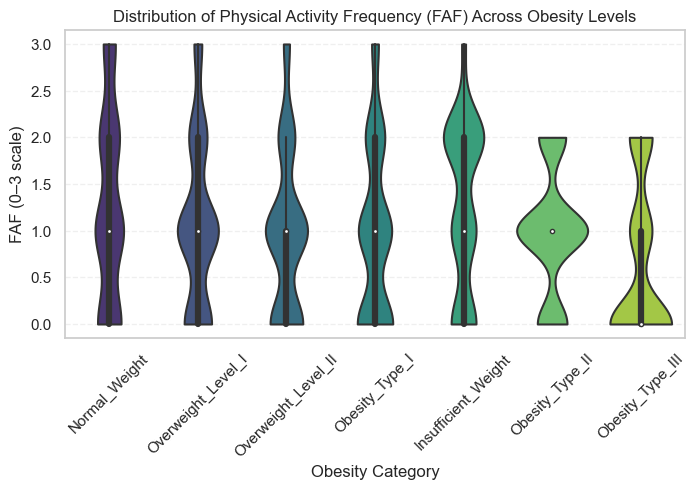

In [59]:
df['FAF_clean'] = df['FAF'].round().astype(int)
plt.figure(figsize=(8,4))
sns.violinplot(
    data=df,
    x='NObeyesdad',
    y='FAF_clean',
    palette='viridis',
    cut=0
)
plt.title("Distribution of Physical Activity Frequency (FAF) Across Obesity Levels")
plt.xlabel("Obesity Category")
plt.ylabel("FAF (0–3 scale)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [60]:
df['TUE'].describe()

count    2111.000000
mean        0.657866
std         0.608927
min         0.000000
25%         0.000000
50%         0.625350
75%         1.000000
max         2.000000
Name: TUE, dtype: float64

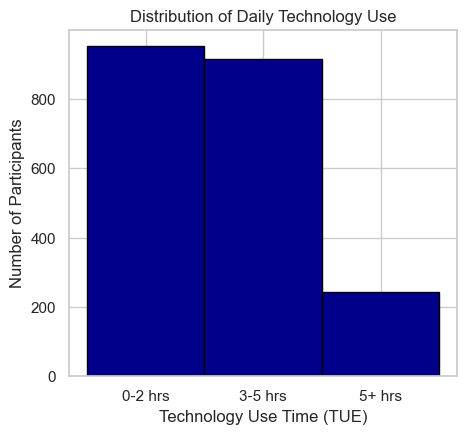

In [61]:
plt.figure(figsize=(5,4.5))
plt.hist(df['TUE'], bins=[-0.5,0.5,1.5,2.5], color='darkblue', edgecolor='black')
plt.xticks([0,1,2], ['0-2 hrs','3-5 hrs','5+ hrs'])
plt.xlabel('Technology Use Time (TUE)')
plt.ylabel('Number of Participants')
plt.title('Distribution of Daily Technology Use')
plt.show()

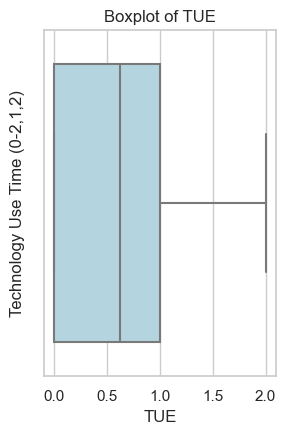

In [62]:
plt.figure(figsize=(3,4.5))
sns.boxplot(x=df['TUE'], color='lightblue')
plt.ylabel('Technology Use Time (0-2,1,2)')
plt.title('Boxplot of TUE')
plt.show()

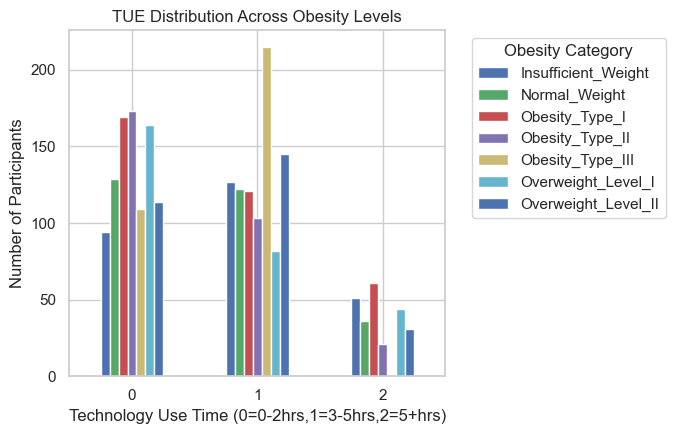

In [63]:
df['TUE'] = df['TUE'].round().astype(int)
df['TUE'] = df['TUE'].clip(0,2)
grouped = df.groupby(['TUE','NObeyesdad']).size().unstack(fill_value=0)
grouped.plot(kind='bar', figsize=(7,4.5), color=['#4C72B0','#55A868','#C44E52','#8172B3','#CCB974','#64B5CD'])
plt.xlabel('Technology Use Time (0=0-2hrs,1=3-5hrs,2=5+hrs)')
plt.ylabel('Number of Participants')
plt.title('TUE Distribution Across Obesity Levels')
plt.legend(title='Obesity Category', bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
contingency_table = pd.crosstab(df['TUE'], df['NObeyesdad'])
contingency_table

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
TUE,,,,,,,
0,94,129,169,173,109,164,114
1,127,122,121,103,215,82,145
2,51,36,61,21,0,44,31


In [65]:
df['TUE'] = df['TUE'].round().astype(int).clip(0,2)

contingency_table = pd.crosstab(df['TUE'], df['NObeyesdad'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("Interpretation: TUE is significantly related to obesity levels.")
else:
    print("Interpretation: TUE is NOT significantly related to obesity levels.")

Chi-square test: χ² = 177.64, p = 0.0000
Interpretation: TUE is significantly related to obesity levels.


In [66]:
# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for TUE vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}. Higher screen time tends to correspond with higher obesity levels.")

Cramér's V for TUE vs Obesity: V = 0.205
Interpretation: weak positive association. Higher screen time tends to correspond with higher obesity levels.


In [67]:
# Contingency table
contingency_table = pd.crosstab(df['FAF'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for FAF vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for FAF vs Obesity: V = 0.208
Interpretation: weak positive association.


In [68]:
# Contingency table
contingency_table = pd.crosstab(df['CH2O'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for CH2O vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for CH2O vs Obesity: V = 0.197
Interpretation: weak positive association.


In [69]:
# Contingency table
contingency_table = pd.crosstab(df['NCP'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for NCP vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for NCP vs Obesity: V = 0.278
Interpretation: weak positive association.


In [70]:
# Contingency table
contingency_table = pd.crosstab(df['FCVC'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for FCVC vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for FCVC vs Obesity: V = 0.486
Interpretation: moderate positive association.


In [71]:
# Contingency table
contingency_table = pd.crosstab(df['SCC'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for SCC vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for SCC vs Obesity: V = 0.241
Interpretation: weak positive association.


In [72]:
# Contingency table
contingency_table = pd.crosstab(df['family_history_with_overweight'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for family_history_with_overweight vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for family_history_with_overweight vs Obesity: V = 0.543
Interpretation: strong positive association.


In [73]:
# Frequency table
gender_counts = df['Gender'].value_counts()
gender_percent = df['Gender'].value_counts(normalize=True) * 100

freq_table = pd.DataFrame({
    'Count': gender_counts,
    'Percentage': gender_percent.round(1)
})
freq_table

,Count,Percentage
Male,1068,50.6
Female,1043,49.4


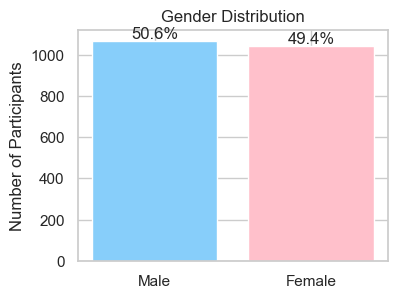

In [74]:
colors = ['lightskyblue', 'pink']
plt.figure(figsize=(4,3))
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors)
for bar, perc in zip(bars, gender_percent):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{perc:.1f}%', ha='center', fontsize=12)
plt.title('Gender Distribution')
plt.ylabel('Number of Participants')
plt.show()

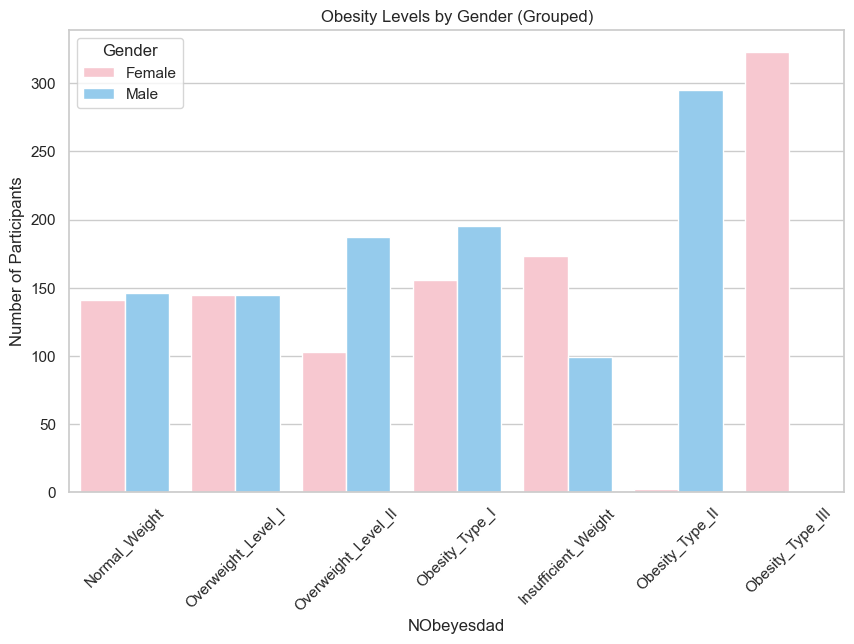

In [75]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='NObeyesdad', hue='Gender', palette=['pink','lightskyblue'])
plt.title('Obesity Levels by Gender (Grouped)')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45) 
plt.show()

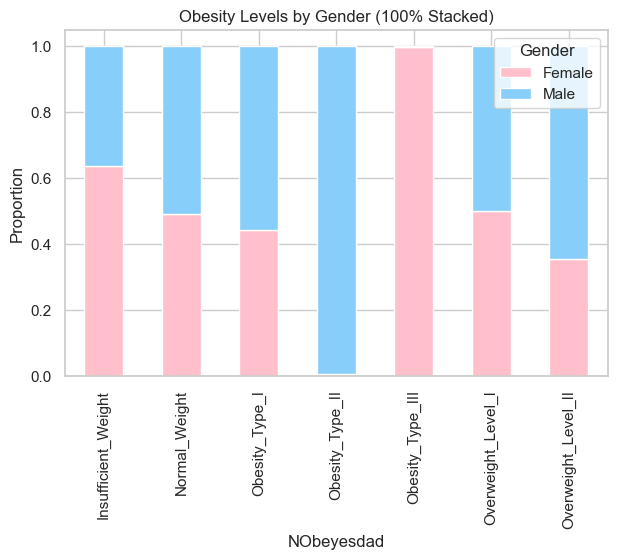

In [76]:
obesity_gender = pd.crosstab(df['NObeyesdad'], df['Gender'])
obesity_gender_percent = obesity_gender.div(obesity_gender.sum(axis=1), axis=0)

obesity_gender_percent.plot(kind='bar', stacked=True, color=['pink','lightskyblue'], figsize=(7,4.5))
plt.ylabel('Proportion')
plt.title('Obesity Levels by Gender (100% Stacked)')
plt.legend(title='Gender', loc='upper right')
plt.show()


In [77]:
# Contingency table
contingency_table = pd.crosstab(df['Gender'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for Gender vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for Gender vs Obesity: V = 0.558
Interpretation: strong positive association.


        Count  Percentage
Male    1068      50.6   
Female  1043      49.4   


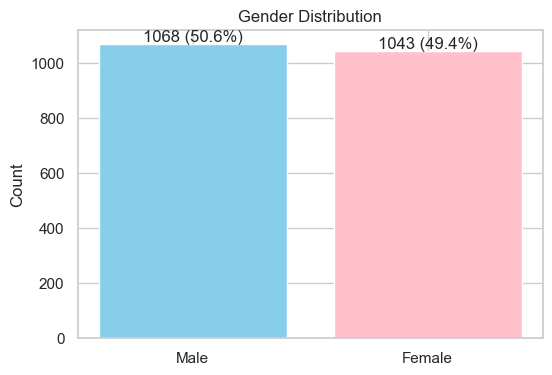

In [78]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()
gender_percent = df['Gender'].value_counts(normalize=True) * 100

# Frequency table
freq_table = pd.DataFrame({
    'Count': gender_counts,
    'Percentage': gender_percent.round(1)
})
print(freq_table)

# Bar chart
plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue','pink'])
for i, val in enumerate(gender_counts.values):
    plt.text(i, val + 10, f'{val} ({gender_percent.values[i]:.1f}%)', ha='center')
plt.title('Gender Distribution')
plt.ylabel('Count')
plt.show()


In [79]:
freq_table = df['family_history_with_overweight'].value_counts().rename_axis("Family History").reset_index(name="Count")
freq_table['Percentage'] = (freq_table['Count'] / freq_table['Count'].sum() * 100).round(1)
freq_table

,Family History,Count,Percentage
0,yes,1726,81.8
1,no,385,18.2


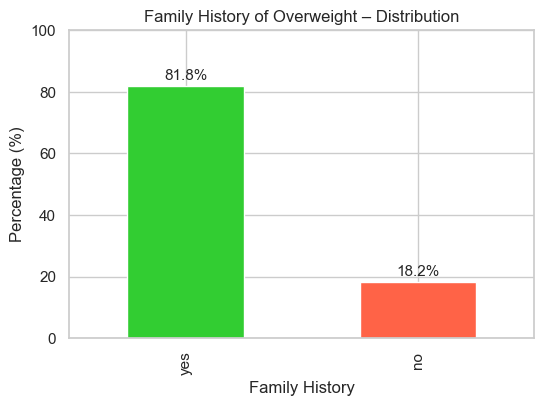

In [80]:
plt.figure(figsize=(6,4))
colors = ['limegreen', 'tomato']  # yes = risk, no = protective
freq_table.set_index("Family History")["Percentage"].plot(kind='bar', color=colors)
plt.title("Family History of Overweight – Distribution")
plt.ylabel("Percentage (%)")
plt.ylim(0,100)
for i, val in enumerate(freq_table["Percentage"]):
    plt.text(i, val + 2, f"{val}%", ha='center', fontsize=11)

plt.show()

In [81]:
favc_table = df['FAVC'].value_counts().rename_axis("FAVC").reset_index(name="Count")
favc_table["Percentage"] = (favc_table["Count"] / favc_table["Count"].sum() * 100).round(1)
favc_table


,FAVC,Count,Percentage
0,yes,1866,88.4
1,no,245,11.6


In [82]:
df['FAVC'].describe()

count     2111
unique       2
top        yes
freq      1866
Name: FAVC, dtype: object

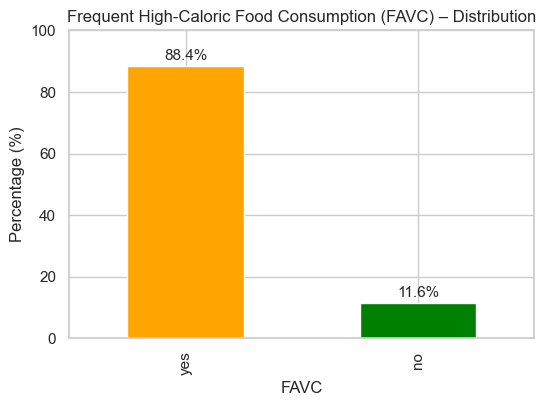

In [83]:
plt.figure(figsize=(6,4))
colors = ['orange', 'green']  # yes = high-calorie, no = protective
favc_table.set_index("FAVC")["Percentage"].plot(kind='bar', color=colors)
plt.title("Frequent High-Caloric Food Consumption (FAVC) – Distribution")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
for i, v in enumerate(favc_table["Percentage"]):
    plt.text(i, v + 2, f"{v}%", ha='center', fontsize=11)
plt.show()

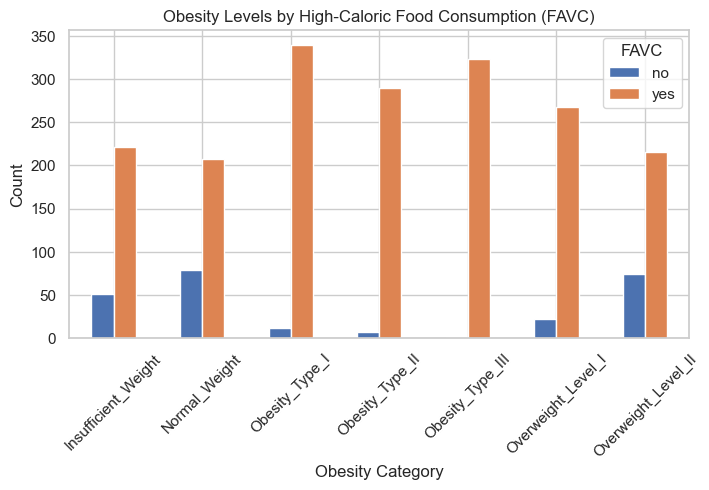

In [84]:
favc_contingency = pd.crosstab(df["FAVC"], df["NObeyesdad"])

favc_contingency.T.plot(kind='bar', figsize=(8,4))
plt.title("Obesity Levels by High-Caloric Food Consumption (FAVC)")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="FAVC")
plt.show()


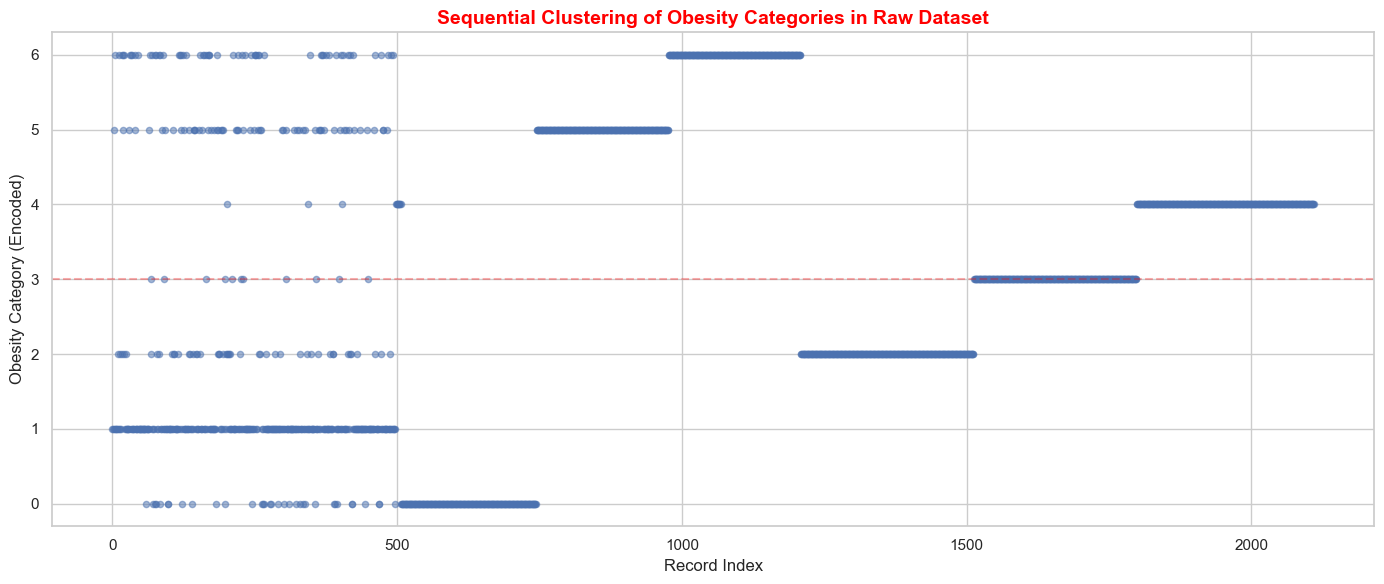

In [85]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(14, 6))
plt.scatter(range(len(df)), df['NObeyesdad'].astype('category').cat.codes,
alpha=0.5, s=20)
plt.xlabel('Record Index', fontsize=12)
plt.ylabel('Obesity Category (Encoded)', fontsize=12)
plt.title('Sequential Clustering of Obesity Categories in Raw Dataset',
fontsize=14, fontweight='bold', color='red')
plt.axhline(y=3, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('data_quality_sequential_issue.png', dpi=300, bbox_inches='tight')
plt.show()

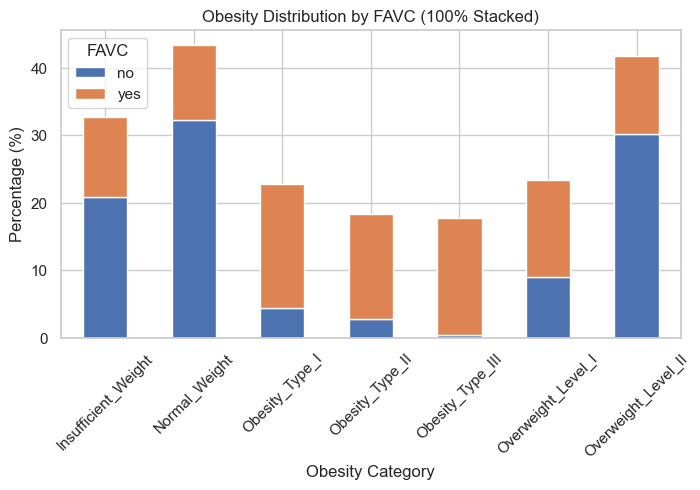

In [86]:
favc_percent = favc_contingency.div(favc_contingency.sum(axis=1), axis=0) * 100

favc_percent.T.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title("Obesity Distribution by FAVC (100% Stacked)")
plt.ylabel("Percentage (%)")
plt.xlabel("Obesity Category")
plt.xticks(rotation=45)
plt.legend(title="FAVC")
plt.show()


In [87]:
contingency_table = pd.crosstab(df['FAVC'], df['NObeyesdad'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("Interpretation: FAVC is significantly related to obesity levels.")
else:
    print("Interpretation: FAVC is NOT significantly related to obesity levels.")

Chi-square test: χ² = 233.34, p = 0.0000
Interpretation: FAVC is significantly related to obesity levels.


In [88]:
# Contingency table
contingency_table = pd.crosstab(df['FAVC'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for FAVC vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for FAVC vs Obesity: V = 0.332
Interpretation: moderate positive association.


In [89]:
contingency_table = pd.crosstab(df['FAVC'], df['NObeyesdad'])
contingency_table

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FAVC,,,,,,,
no,51,79,11,7,1,22,74
yes,221,208,340,290,323,268,216


In [90]:
caec_counts = df['CAEC'].value_counts().sort_index()
caec_percent = round(df['CAEC'].value_counts(normalize=True).sort_index() * 100, 1)
caec_table = pd.DataFrame({'Count': caec_counts, 'Percentage': caec_percent})
caec_table

,Count,Percentage
Always,53,2.5
Frequently,242,11.5
Sometimes,1765,83.6
no,51,2.4


In [91]:
df['CAEC'].describe()

count          2111
unique            4
top       Sometimes
freq           1765
Name: CAEC, dtype: object

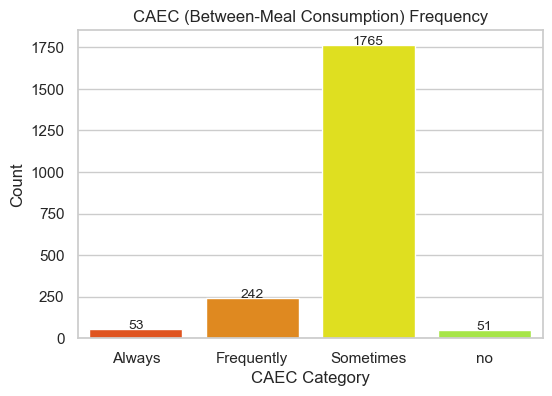

In [92]:
colors = ['orangered', 'darkorange', 'yellow', 'greenyellow']
plt.figure(figsize=(6,4))
sns.barplot(x=caec_table.index, y=caec_table['Count'], palette=colors)
for i, v in enumerate(caec_table['Count']):
    plt.text(i, v + 2, str(v), ha='center', fontsize=10)
plt.title('CAEC (Between-Meal Consumption) Frequency')
plt.ylabel('Count')
plt.xlabel('CAEC Category')
plt.show()

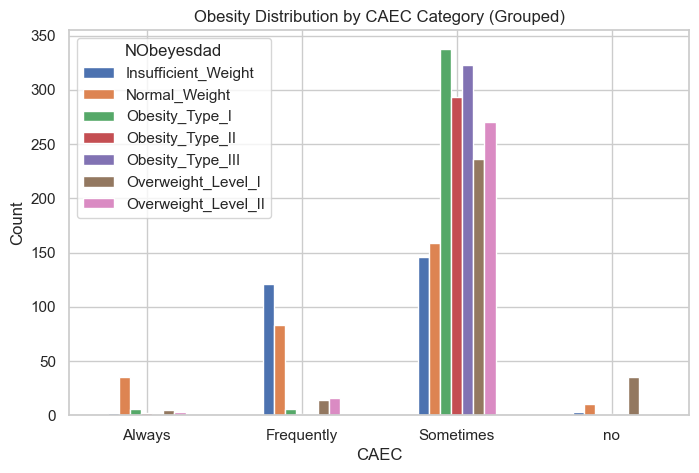

In [93]:
caec_obesity = pd.crosstab(df['CAEC'], df['NObeyesdad'])
caec_obesity.plot(kind='bar', figsize=(8,5))
plt.title('Obesity Distribution by CAEC Category (Grouped)')
plt.ylabel('Count')
plt.xlabel('CAEC')
plt.xticks(rotation=0)
plt.show()

In [94]:
caec_obesity

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CAEC,,,,,,,
Always,2,35,6,2,0,5,3
Frequently,121,83,6,1,1,14,16
Sometimes,146,159,338,293,323,236,270
no,3,10,1,1,0,35,1


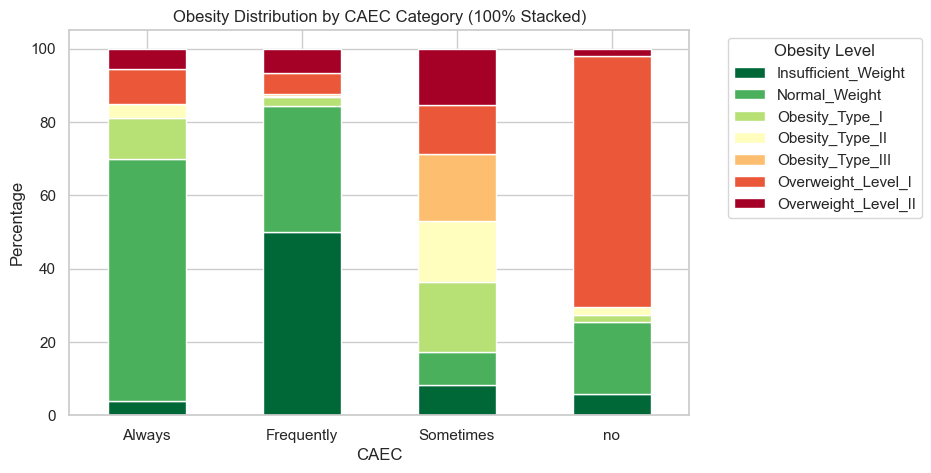

In [95]:
caec_obesity_pct = caec_obesity.div(caec_obesity.sum(axis=1), axis=0) * 100
caec_obesity_pct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='RdYlGn_r')
plt.title('Obesity Distribution by CAEC Category (100% Stacked)')
plt.ylabel('Percentage')
plt.xlabel('CAEC')
plt.xticks(rotation=0)
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [96]:
contingency_table = pd.crosstab(df['CAEC'], df['NObeyesdad'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("Interpretation: CAEC is significantly related to obesity levels.")
else:
    print("Interpretation: CAEC is NOT significantly related to obesity levels.")

Chi-square test: χ² = 802.98, p = 0.0000
Interpretation: CAEC is significantly related to obesity levels.


In [97]:
# Contingency table
contingency_table = pd.crosstab(df['CAEC'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for CAEC vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for CAEC vs Obesity: V = 0.356
Interpretation: moderate positive association.


In [98]:
df['SMOKE'].describe()

count     2111
unique       2
top         no
freq      2067
Name: SMOKE, dtype: object

In [99]:
smoke_counts = df['SMOKE'].value_counts()
smoke_percent = df['SMOKE'].value_counts(normalize=True) * 100
smoke_table = pd.DataFrame({'Count': smoke_counts, 'Percentage': smoke_percent.round(2)})
smoke_table

,Count,Percentage
no,2067,97.92
yes,44,2.08


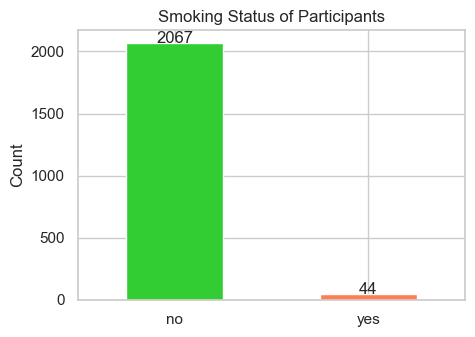

In [100]:
plt.figure(figsize=(5,3.5))
colors = ['limegreen', 'coral']
smoke_counts.plot(kind='bar', color=colors)
plt.title('Smoking Status of Participants')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, val in enumerate(smoke_counts):
    plt.text(i, val+5, str(val), ha='center')
plt.show()

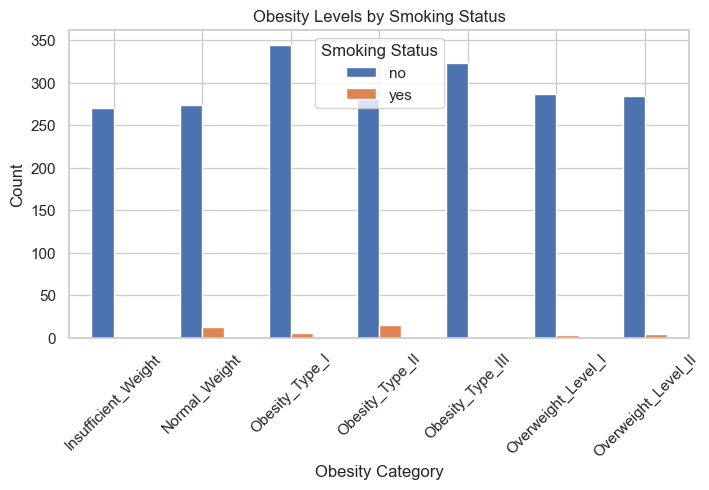

In [101]:
smoke_obesity = pd.crosstab(df['NObeyesdad'], df['SMOKE'])
smoke_obesity.plot(kind='bar', figsize=(8,4))
plt.title('Obesity Levels by Smoking Status')
plt.ylabel('Count')
plt.xlabel('Obesity Category')
plt.xticks(rotation=45)
plt.legend(title='Smoking Status')
plt.show()

In [102]:
contingency_table = pd.crosstab(df['SMOKE'], df['NObeyesdad'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("Interpretation: SMOKE is significantly related to obesity levels.")
else:
    print("Interpretation: SMOKE is NOT significantly related to obesity levels.")

Chi-square test: χ² = 32.14, p = 0.0000
Interpretation: SMOKE is significantly related to obesity levels.


In [103]:
contingency_table = pd.crosstab(df['SMOKE'], df['NObeyesdad'])
contingency_table

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SMOKE,,,,,,,
no,271,274,345,282,323,287,285
yes,1,13,6,15,1,3,5


In [104]:
# Contingency table
contingency_table = pd.crosstab(df['SMOKE'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for SMOKE vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for SMOKE vs Obesity: V = 0.123
Interpretation: weak positive association.


In [105]:
df['SCC'].describe()

count     2111
unique       2
top         no
freq      2015
Name: SCC, dtype: object

In [106]:
smoke_counts = df['SCC'].value_counts()
smoke_percent = df['SCC'].value_counts(normalize=True) * 100
smoke_table = pd.DataFrame({'Count': smoke_counts, 'Percentage': smoke_percent.round(2)})
smoke_table

,Count,Percentage
no,2015,95.45
yes,96,4.55


In [107]:
df['CALC'].describe()

count          2111
unique            4
top       Sometimes
freq           1401
Name: CALC, dtype: object

In [108]:
calc_counts = df['CALC'].value_counts()
calc_percent = df['CALC'].value_counts(normalize=True) * 100
calc_table = pd.DataFrame({'Count': smoke_counts, 'Percentage': calc_percent.round(2)})
calc_table

,Count,Percentage
Always,NaN,0.05
Frequently,NaN,3.32
Sometimes,NaN,66.37
no,2015.0,30.27
yes,96.0,NaN


In [109]:
calc_counts = df['CALC'].value_counts()
calc_percent = df['CALC'].value_counts(normalize=True) * 100
calc_table = pd.DataFrame({'Count': calc_counts, 'Percentage': calc_percent.round(2)})
calc_table

,Count,Percentage
Sometimes,1401,66.37
no,639,30.27
Frequently,70,3.32
Always,1,0.05


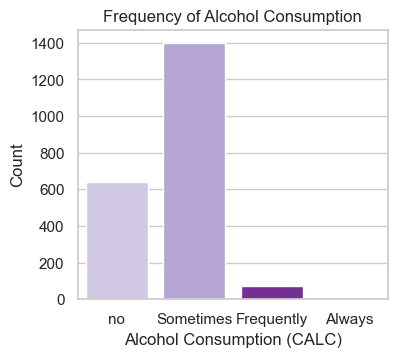

In [110]:
sns.set_style("whitegrid")
calc_order = ['no', 'Sometimes', 'Frequently', 'Always']  # to maintain order
colors = ['#d1c4e9', '#b39ddb', '#7b1fa2', '#4a148c']  # gradient purple→dark red

plt.figure(figsize=(4,3.5))
sns.barplot(x=calc_table.index, y='Count', data=calc_table.reset_index(), order=calc_order, palette=colors)
plt.ylabel('Count')
plt.xlabel('Alcohol Consumption (CALC)')
plt.title('Frequency of Alcohol Consumption')
plt.show()

In [111]:
contingency_table = pd.crosstab(df['CALC'], df['NObeyesdad'])
contingency_table

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CALC,,,,,,,
Always,0,1,0,0,0,0,0
Frequently,1,18,14,2,0,16,19
Sometimes,154,161,172,224,323,224,143
no,117,107,165,71,1,50,128


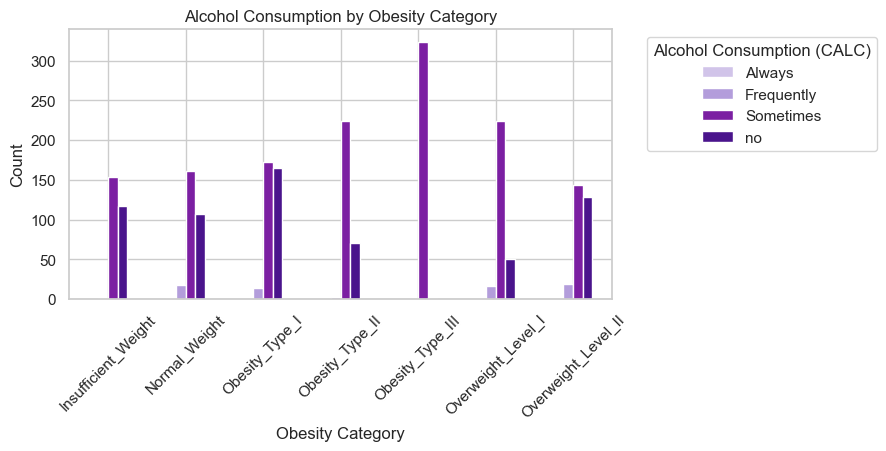

In [112]:
calc_obesity = df.groupby('NObeyesdad')['CALC'].value_counts().unstack()
colors = ['#d1c4e9', '#b39ddb', '#7b1fa2', '#4a148c']

calc_obesity.plot(kind='bar', figsize=(7,3.5), color=colors)
plt.ylabel('Count')
plt.xlabel('Obesity Category')
plt.title('Alcohol Consumption by Obesity Category')
plt.xticks(rotation=45)
plt.legend(title='Alcohol Consumption (CALC)', bbox_to_anchor=(1.05, 1))
plt.show()

In [113]:
contingency_table = pd.crosstab(df['CALC'], df['NObeyesdad'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("Interpretation: SMOKE is significantly related to obesity levels.")
else:
    print("Interpretation: SMOKE is NOT significantly related to obesity levels.")

Chi-square test: χ² = 338.58, p = 0.0000
Interpretation: SMOKE is significantly related to obesity levels.


In [114]:
# Contingency table
contingency_table = pd.crosstab(df['CALC'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for CALC vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for CALC vs Obesity: V = 0.231
Interpretation: weak positive association.


<Figure size 1400x600 with 0 Axes>

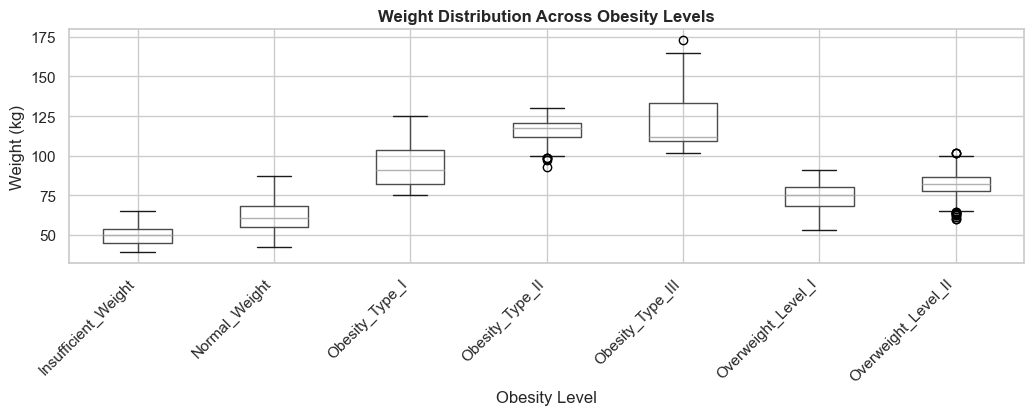

ANOVA: F=1966.52, p=0.0000


In [115]:
plt.figure(figsize=(14, 6))
df.boxplot(column='Weight', by='NObeyesdad', figsize=(10.5, 4.5))
plt.suptitle('')
plt.title('Weight Distribution Across Obesity Levels', fontweight='bold')
plt.xlabel('Obesity Level')
plt.ylabel('Weight (kg)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('weight_by_obesity.png', dpi=300, bbox_inches='tight')
plt.show()

# ANOVA
from scipy import stats
groups = [df[df['NObeyesdad']==level]['Weight'] for level in df['NObeyesdad'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.2f}, p={p_val:.4f}")

In [116]:
mean_weights = df.groupby('NObeyesdad')['Weight'].mean()
print(mean_weights)

NObeyesdad
Insufficient_Weight     49.906330
Normal_Weight           62.155052
Obesity_Type_I          92.870198
Obesity_Type_II        115.305311
Obesity_Type_III       120.941114
Overweight_Level_I      74.266828
Overweight_Level_II     82.085271
Name: Weight, dtype: float64


<Figure size 1400x600 with 0 Axes>

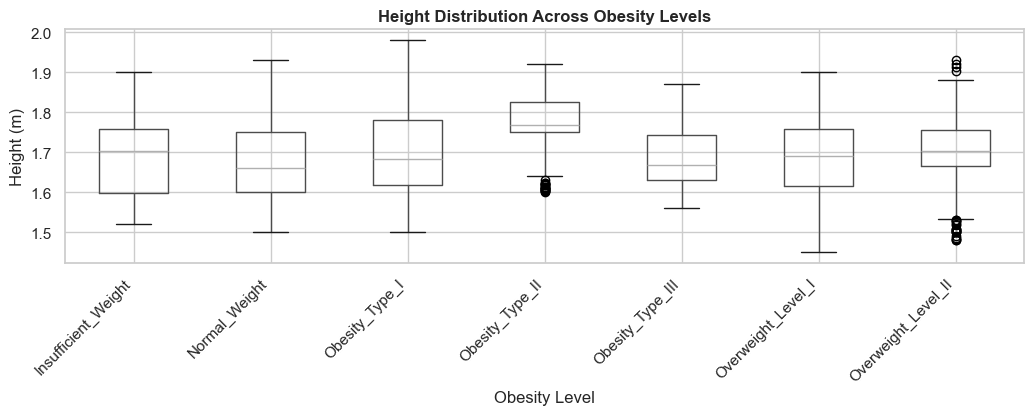

ANOVA (Height): F=38.43, p=0.0000


In [117]:
plt.figure(figsize=(14, 6))
df.boxplot(column='Height', by='NObeyesdad', figsize=(10.5, 4.5))
plt.suptitle('')
plt.title('Height Distribution Across Obesity Levels', fontweight='bold')
plt.xlabel('Obesity Level')
plt.ylabel('Height (m)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('height_by_obesity.png', dpi=300, bbox_inches='tight')
plt.show()
groups_height = [df[df['NObeyesdad'] == level]['Height'] for level in df['NObeyesdad'].unique()]

# ANOVA
f_stat_h, p_val_h = stats.f_oneway(*groups_height)
print(f"ANOVA (Height): F={f_stat_h:.2f}, p={p_val_h:.4f}")

In [118]:
mean_heights = df.groupby('NObeyesdad')['Height'].mean()
print(mean_heights)

NObeyesdad
Insufficient_Weight    1.691117
Normal_Weight          1.676585
Obesity_Type_I         1.693804
Obesity_Type_II        1.771795
Obesity_Type_III       1.687559
Overweight_Level_I     1.687836
Overweight_Level_II    1.703748
Name: Height, dtype: float64


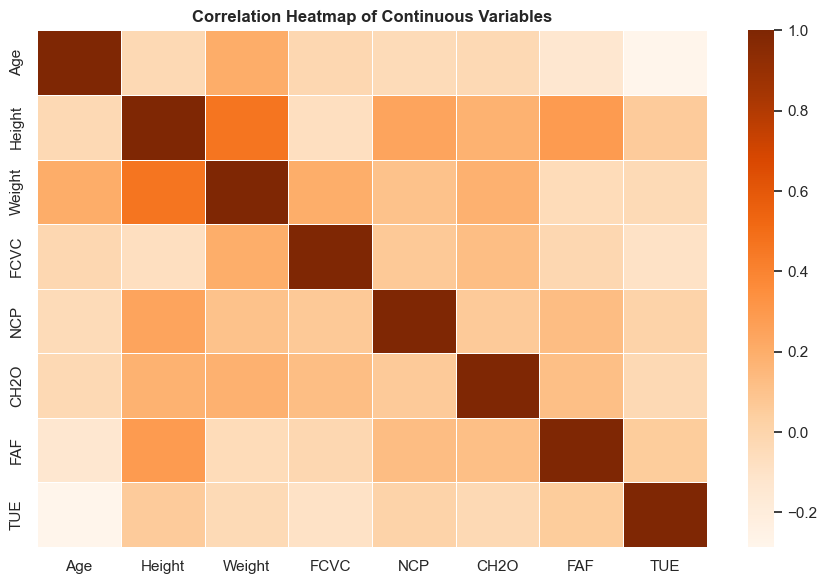

In [119]:
plt.figure(figsize=(9, 6))
corr_matrix = df.drop(columns=["FAF_clean"]).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap='Oranges', linewidths=0.5)
plt.title('Correlation Heatmap of Continuous Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

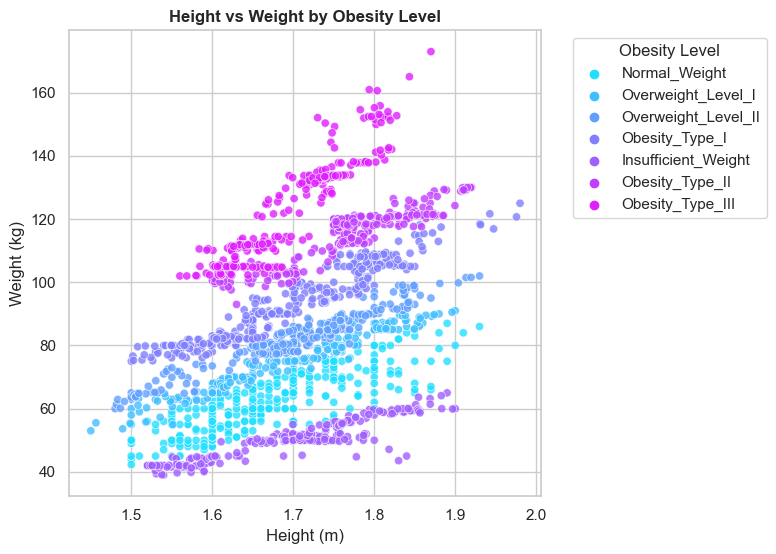

In [120]:
plt.figure(figsize=(8,5.7))
sns.scatterplot(
    data=df,
    x='Height',
    y='Weight',
    hue='NObeyesdad',
    palette='cool',
    alpha=0.8
)
plt.title('Height vs Weight by Obesity Level', fontweight='bold')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('height_vs_weight.png', dpi=300, bbox_inches='tight')
plt.show()

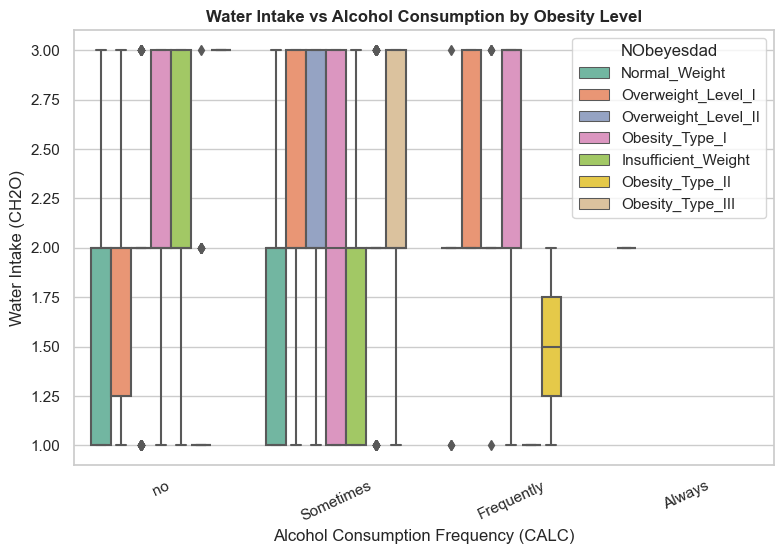

In [121]:
plt.figure(figsize=(8,5.7))
sns.boxplot(
    data=df,
    x='CALC',
    y='CH2O',
    hue='NObeyesdad',
    palette='Set2'
)
plt.title('Water Intake vs Alcohol Consumption by Obesity Level', fontweight='bold')
plt.xlabel('Alcohol Consumption Frequency (CALC)')
plt.ylabel('Water Intake (CH2O)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('calc_ch2o_obesity.png', dpi=300, bbox_inches='tight')
plt.show()

In [122]:
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))
results = []
categorical_vars = [
    'Gender', 'family_history_with_overweight', 'CALC',
    'FAVC', 'SMOKE', 'SCC', 'CAEC', 'MTRANS'
]
for var in categorical_vars:
    table = pd.crosstab(df[var], df['NObeyesdad'])
    chi2, p, dof, exp = stats.chi2_contingency(table)
    v = cramers_v(table)
    results.append({
        "Variable": var,
        "Chi-square": round(chi2, 2),
        "p-value": round(p, 4),
        "Cramer's V": round(v, 3)
    })
summary_table = pd.DataFrame(results)
summary_table

,Variable,Chi-square,p-value,Cramer's V
0,Gender,657.75,0.0,0.558
1,family_history_with_overweight,621.98,0.0,0.543
2,CALC,338.58,0.0,0.231
3,FAVC,233.34,0.0,0.332
4,SMOKE,32.14,0.0,0.123
5,SCC,123.02,0.0,0.241
6,CAEC,802.98,0.0,0.356
7,MTRANS,292.59,0.0,0.186


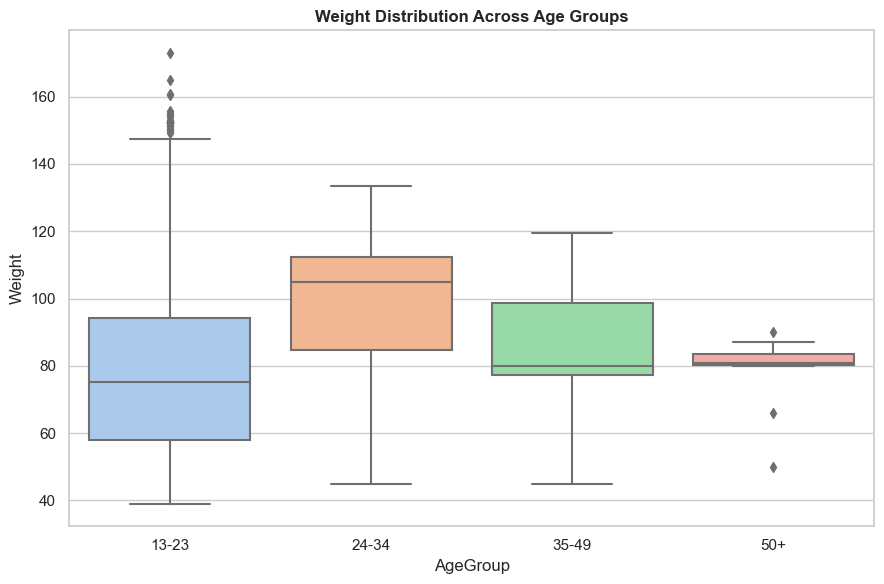

In [123]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='AgeGroup', y='Weight', palette='pastel')
plt.title('Weight Distribution Across Age Groups', fontweight='bold')
plt.tight_layout()
plt.show()


In [124]:
contingency_table = pd.crosstab(df['Gender'], df['NObeyesdad'])
contingency_table

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,173,141,156,2,323,145,103
Male,99,146,195,295,1,145,187


In [125]:
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p:.4f}")
if p < 0.05:
    print("Interpretation: Gender is significantly related to obesity levels.")
else:
    print("Interpretation: Gender is NOT significantly related to obesity levels.")

Chi-square test: χ² = 657.75, p = 0.0000
Interpretation: Gender is significantly related to obesity levels.


In [126]:
# Contingency table
contingency_table = pd.crosstab(df['Gender'], df['NObeyesdad'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

# Automatic interpretation
if cramers_v < 0.1:
    interpretation = "negligible association"
elif cramers_v < 0.3:
    interpretation = "weak positive association"
elif cramers_v < 0.5:
    interpretation = "moderate positive association"
else:
    interpretation = "strong positive association"

# Display results
print(f"Cramér's V for Gender vs Obesity: V = {cramers_v:.3f}")
print(f"Interpretation: {interpretation}.")

Cramér's V for Gender vs Obesity: V = 0.558
Interpretation: strong positive association.


In [127]:
df = df.drop_duplicates().reset_index(drop=True)
print("New shape after removing duplicates: ", df.shape)

New shape after removing duplicates:  (2087, 20)


Gender: {'Female': 0, 'Male': 1}
CAEC: {'Always': 0, 'Frequently': 1, 'Sometimes': 2, 'no': 3}
CALC: {'Always': 0, 'Frequently': 1, 'Sometimes': 2, 'no': 3}
MTRANS: {'Automobile': 0, 'Bike': 1, 'Motorbike': 2, 'Public_Transportation': 3, 'Walking': 4}

Target encoding (ordinal): {'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6}
Features shape: (2087, 16)
Features: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']
Training: (1669, 16), Testing: (418, 16)
Training Accuracy: 1.0000
Testing Accuracy: 0.9354


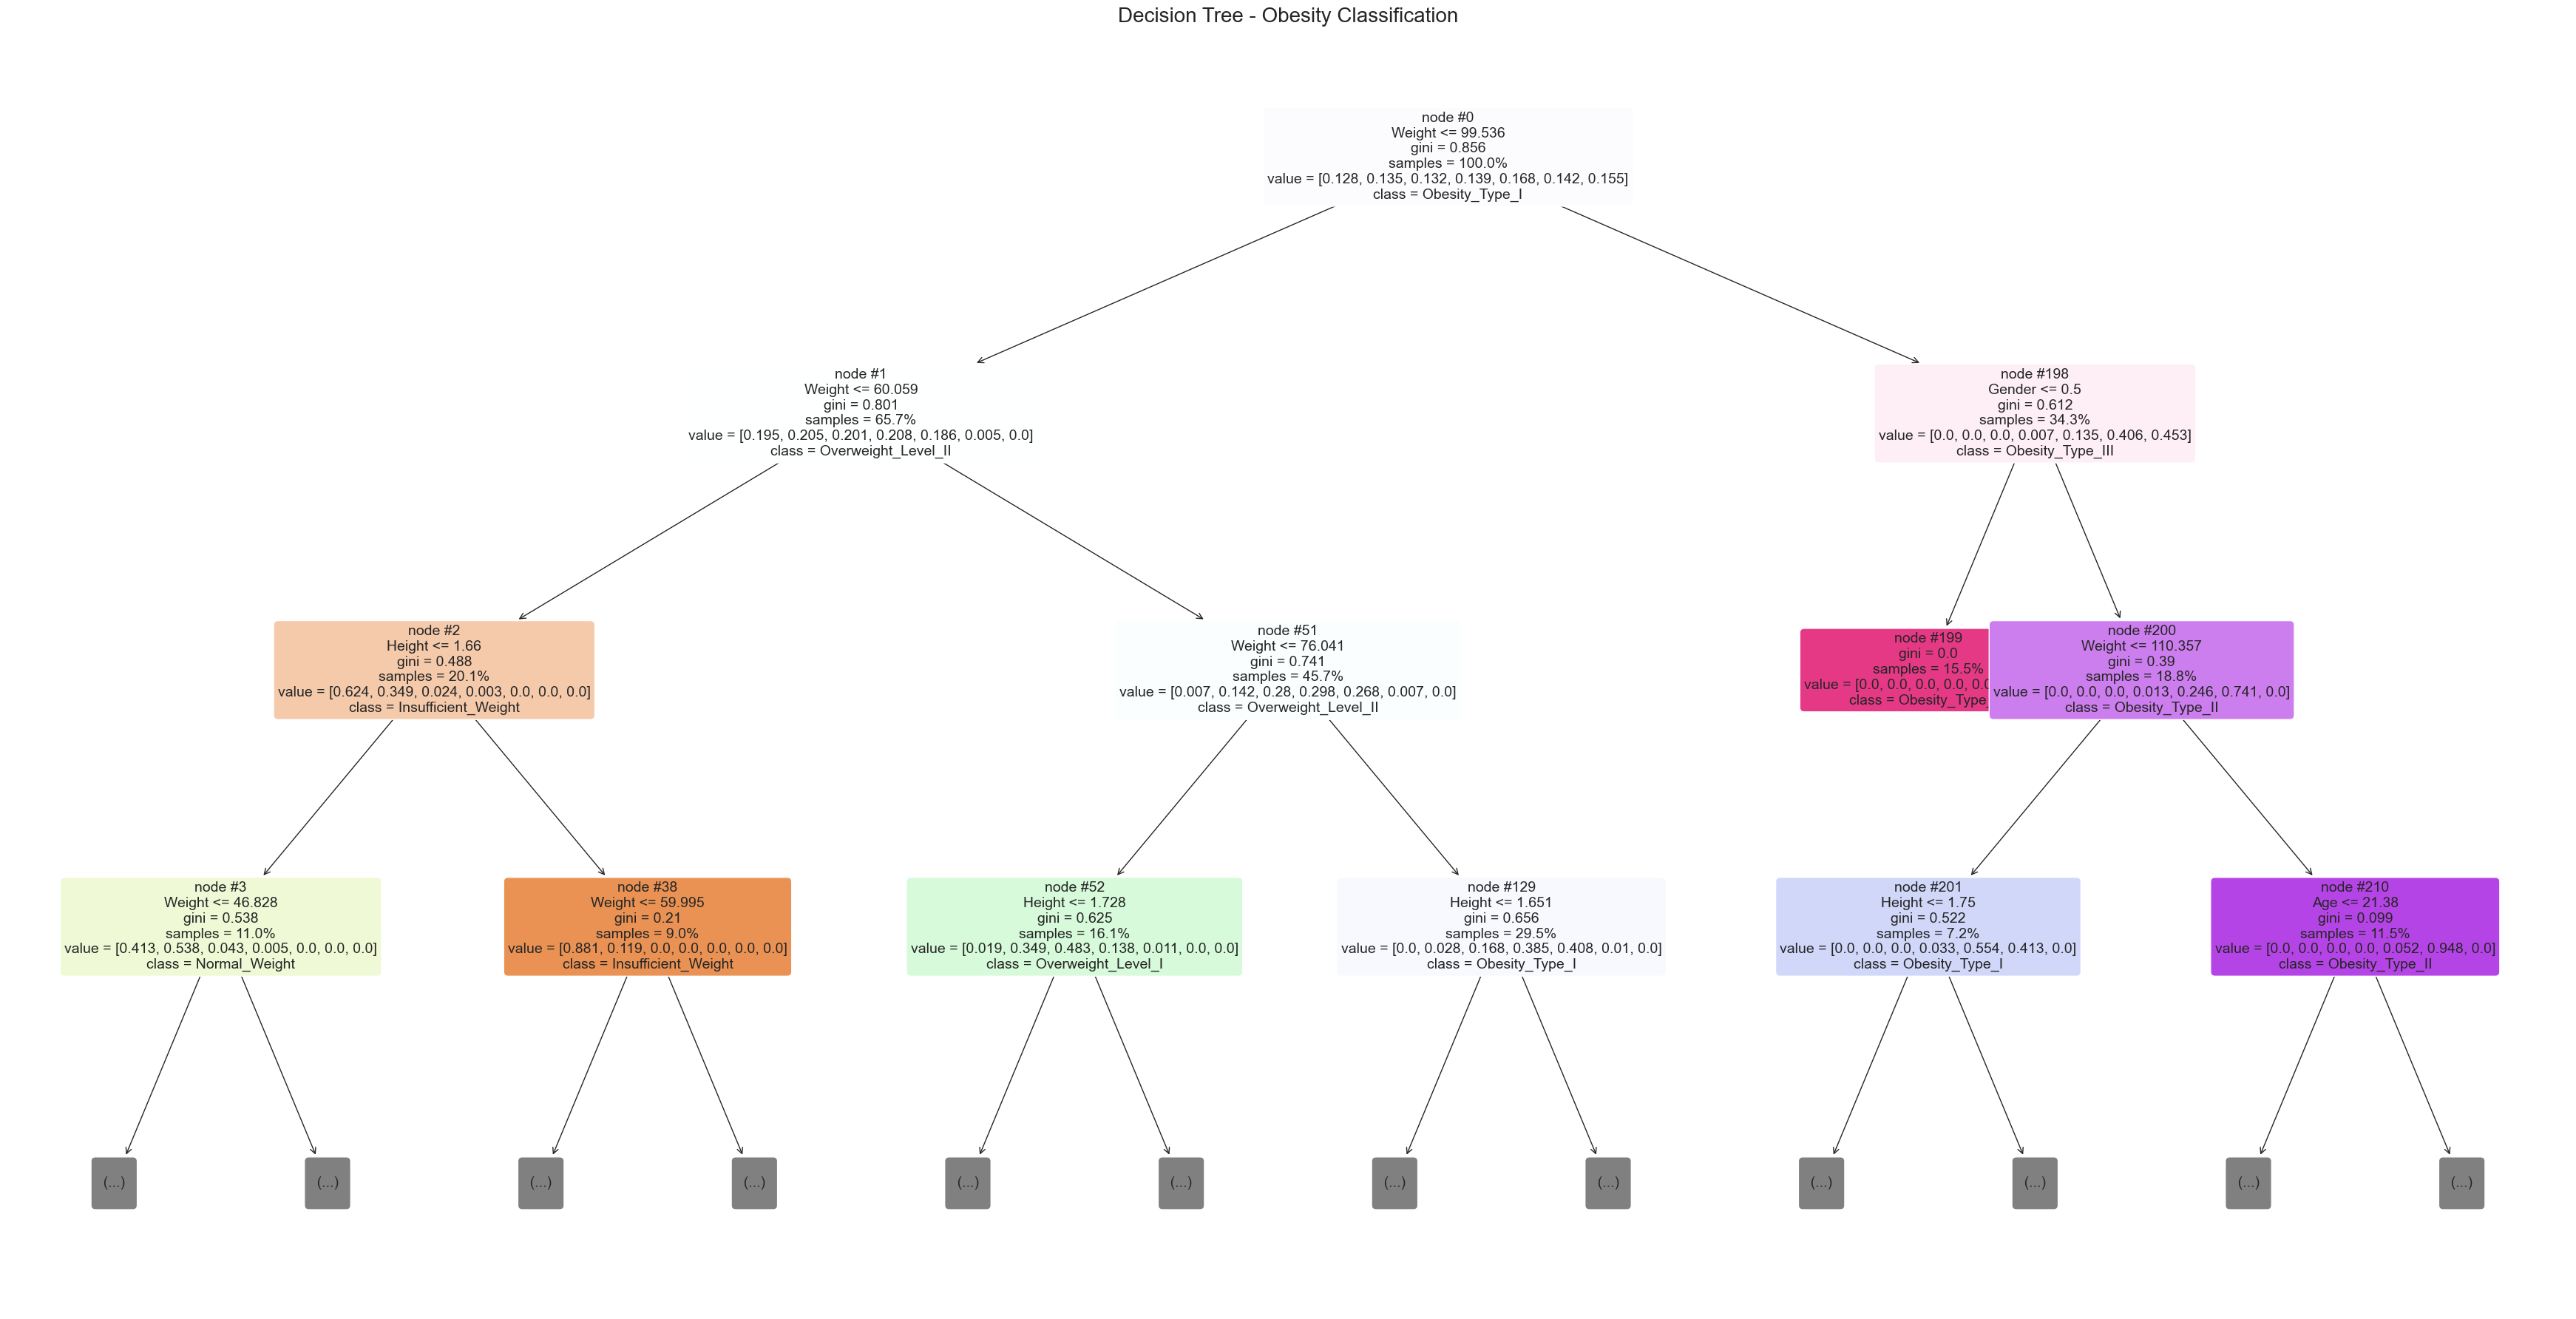


=== ENCODING REFERENCE ===

Binary Variables (yes=1, no=0):
- family_history_with_overweight
- FAVC
- SMOKE
- SCC

Categorical Encodings:

Gender:
  Female = 0
  Male = 1

CAEC:
  Always = 0
  Frequently = 1
  Sometimes = 2
  no = 3

CALC:
  Always = 0
  Frequently = 1
  Sometimes = 2
  no = 3

MTRANS:
  Automobile = 0
  Bike = 1
  Motorbike = 2
  Public_Transportation = 3
  Walking = 4

Target Variable (NObeyesdad):
  Insufficient_Weight = 0
  Normal_Weight = 1
  Overweight_Level_I = 2
  Overweight_Level_II = 3
  Obesity_Type_I = 4
  Obesity_Type_II = 5
  Obesity_Type_III = 6


In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Encode all categorical and binary variables
df_encoded = df.copy()

# Binary columns (yes/no)
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

# Categorical columns
categorical_cols = ['Gender', 'CAEC', 'CALC', 'MTRANS']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target variable in CORRECT ORDINAL ORDER
obesity_order = [
    'Insufficient_Weight',
    'Normal_Weight', 
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

obesity_mapping = {label: idx for idx, label in enumerate(obesity_order)}
df_encoded['NObeyesdad_encoded'] = df_encoded['NObeyesdad'].map(obesity_mapping)

target_encoder = LabelEncoder()
target_encoder.classes_ = np.array(obesity_order)

print(f"\nTarget encoding (ordinal): {obesity_mapping}")

# Prepare features and target + excl. temporary columns
exclude_cols = ['NObeyesdad', 'NObeyesdad_encoded', 'AgeGroup', 'CH2O_cat', 'FAF_clean']
X_encoded = df_encoded.drop(columns=exclude_cols, errors='ignore')
y = df_encoded['NObeyesdad_encoded']
print(f"Features shape: {X_encoded.shape}")
print(f"Features: {list(X_encoded.columns)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training: {X_train.shape}, Testing: {X_test.shape}")

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print(f"Training Accuracy: {dt.score(X_train, y_train):.4f}")
print(f"Testing Accuracy: {dt.score(X_test, y_test):.4f}")

# Visualize Decision Tree
plt.figure(figsize=(35, 18))
plot_tree(
    dt,
    feature_names=X_encoded.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=14,
    max_depth=3,
    proportion=True,
    node_ids=True,
    impurity=True,
    label='all'
)
plt.title("Decision Tree - Obesity Classification", fontsize=20)
plt.tight_layout()
plt.show()

# Display encoding mappings
print("\n=== ENCODING REFERENCE ===")
print("\nBinary Variables (yes=1, no=0):")
print("- family_history_with_overweight")
print("- FAVC")
print("- SMOKE")
print("- SCC")

print("\nCategorical Encodings:")
for col in categorical_cols:
    print(f"\n{col}:")
    for original, encoded in zip(label_encoders[col].classes_, 
                                  label_encoders[col].transform(label_encoders[col].classes_)):
        print(f"  {original} = {encoded}")

print("\nTarget Variable (NObeyesdad):")
for original, encoded in zip(target_encoder.classes_, 
                              target_encoder.transform(target_encoder.classes_)):
    print(f"  {original} = {encoded}")

In [129]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad', 'AgeGroup', 'CH2O_cat', 'FAF_clean'], dtype='object')

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.86      0.89      0.88        57
 Overweight_Level_I       0.88      0.80      0.84        55
Overweight_Level_II       0.96      0.93      0.95        58
     Obesity_Type_I       0.90      0.99      0.94        70
    Obesity_Type_II       0.98      0.93      0.96        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.94       418
          macro avg       0.94      0.93      0.93       418
       weighted avg       0.94      0.94      0.93       418



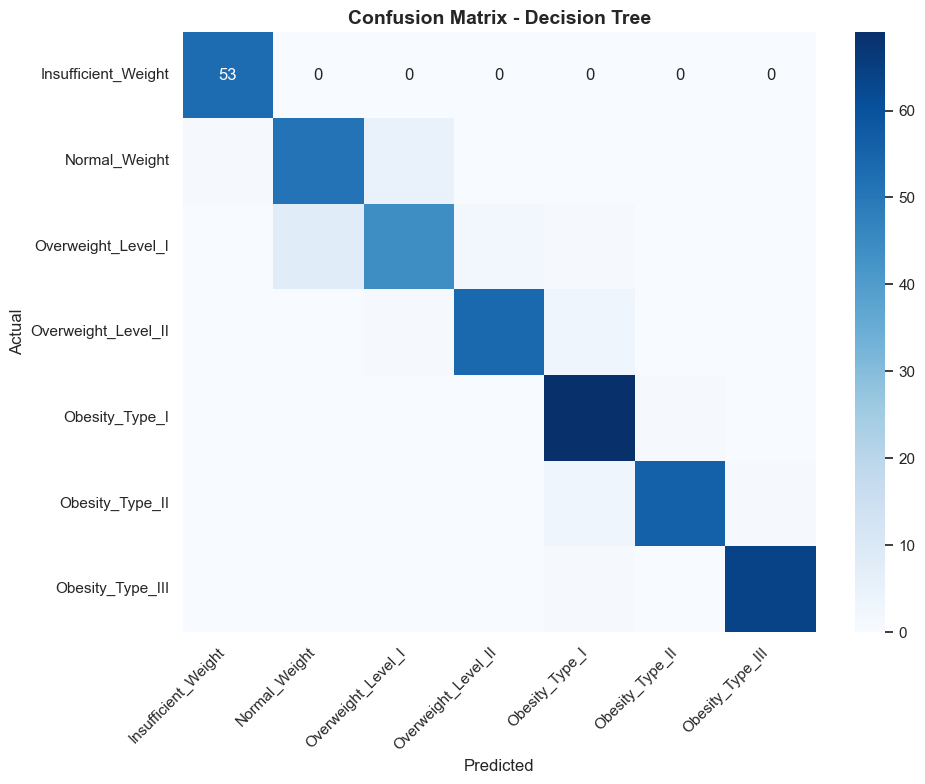

In [130]:
# Decision Tree Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred_dt = dt.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=target_encoder.classes_))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [131]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(cm_dt)
print("\nClass labels in order:")
print(target_encoder.classes_)

Confusion Matrix:
[[53  0  0  0  0  0  0]
 [ 1 51  5  0  0  0  0]
 [ 0  8 44  2  1  0  0]
 [ 0  0  1 54  3  0  0]
 [ 0  0  0  0 69  1  0]
 [ 0  0  0  0  3 56  1]
 [ 0  0  0  0  1  0 64]]

Class labels in order:
['Insufficient_Weight' 'Normal_Weight' 'Overweight_Level_I'
 'Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III']


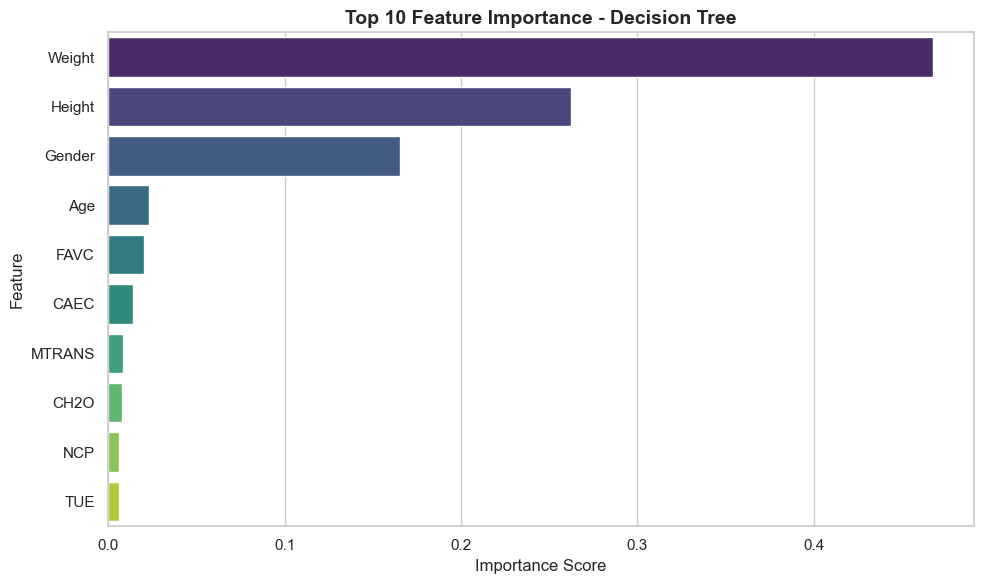

Top 10 Most Important Features:
Feature  Importance
 Weight   0.467457 
 Height   0.262493 
 Gender   0.165411 
    Age   0.023211 
   FAVC   0.020405 
   CAEC   0.014122 
 MTRANS   0.008698 
   CH2O   0.007590 
    NCP   0.006124 
    TUE   0.006092 


In [132]:
feature_importance_dt = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_dt.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance_dt.head(10).to_string(index=False))

In [ ]:
# ===============================
# K-Nearest Neighbor on Obesity Dataset
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score



#1) Load dataset
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

df = df.drop_duplicates().reset_index(drop=True)


# Preview
print()
print(df.head())
print()
print("New Shape after removing duplicated data:", df.shape) 
print()

le = LabelEncoder()
y = le.fit_transform(df["NObeyesdad"])


# 2) Separate features and target
X = df.drop("NObeyesdad", axis=1)



# 3) Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical:", cat_cols)
print()
print("Numeric:", num_cols)
print()

# 4) Build preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

# 5) Build KNN pipeline

knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier() )
])


# 6) Train the model

param_grid = {
    "model__n_neighbors": [3, 5, 7],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"],
    "model__p": [2], 
    "model__algorithm": ["auto", "kd_tree"],
    "model__leaf_size": [30]
}


# 7) Random Search
random_search = RandomizedSearchCV(
    knn,
    param_distributions=param_grid,
    n_iter= 20,               # try 20 random combinations
    cv=5,
    scoring="f1_weighted",
    n_jobs= -1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)
print("\nBest parameters:", random_search.best_params_)



# 8) Predictions
best_knn = random_search.best_estimator_

y_pred = best_knn.predict(X_test)
knn_test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nKNN Test Accuracy: {knn_test_accuracy:.4f}")

# 9) Evaluation
print()
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print()

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print()

# 10)Confusion Matrix Visualization

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix – KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=range(len(le.classes_)), labels=le.classes_, rotation=45)
plt.yticks(ticks=range(len(le.classes_)), labels=le.classes_)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# 11)K-Value Comparison Graph
from sklearn.model_selection import cross_val_score

# Test different k values
k_values = [1, 3, 5, 7, 9, 11, 15, 19, 25]
train_scores = []
test_scores = []
cv_scores_list = []

# Get the preprocessed data from the pipeline
X_train_transformed = best_knn.named_steps['preprocess'].transform(X_train)
X_test_transformed = best_knn.named_steps['preprocess'].transform(X_test)

print("Testing different k values...")
for k in k_values:
    # Create KNN with current k
    knn_temp = KNeighborsClassifier(n_neighbors=k, weights='distance')
    
    # Fit and score
    knn_temp.fit(X_train_transformed, y_train)
    train_scores.append(knn_temp.score(X_train_transformed, y_train))
    test_scores.append(knn_temp.score(X_test_transformed, y_test))
    
    # Cross-validation score
    cv_score = cross_val_score(knn_temp, X_train_transformed, y_train, cv=5, scoring='accuracy').mean()
    cv_scores_list.append(cv_score)
    
    print(f"k={k}: Train={train_scores[-1]:.4f}, Test={test_scores[-1]:.4f}, CV={cv_score:.4f}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, marker='o', linewidth=2, markersize=8, label='Train Accuracy')
plt.plot(k_values, test_scores, marker='s', linewidth=2, markersize=8, label='Test Accuracy')
plt.plot(k_values, cv_scores_list, marker='^', linewidth=2, markersize=8, label='CV Accuracy')
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Performance vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Print best k
best_k_idx = np.argmax(cv_scores_list)
print(f"\nOptimal k value: {k_values[best_k_idx]}")
print(f"Best CV Score: {cv_scores_list[best_k_idx]:.4f}")


   Gender   Age  Height  Weight family_history_with_overweight  ... FAF   TUE     CALC            MTRANS              NObeyesdad     
0  Female  21.0   1.62    64.0                yes               ...  0.0  1.0          no  Public_Transportation        Normal_Weight
1  Female  21.0   1.52    56.0                yes               ...  3.0  0.0   Sometimes  Public_Transportation        Normal_Weight
2    Male  23.0   1.80    77.0                yes               ...  2.0  1.0  Frequently  Public_Transportation        Normal_Weight
3    Male  27.0   1.80    87.0                 no               ...  2.0  0.0  Frequently                Walking   Overweight_Level_I
4    Male  22.0   1.78    89.8                 no               ...  0.0  0.0   Sometimes  Public_Transportation  Overweight_Level_II

[5 rows x 17 columns]

New Shape after removing duplicated data: (2087, 17)

Categorical: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Numeric: